<a href="https://colab.research.google.com/github/ekomissarov/sutva-tsm/blob/main/two_sided_market_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impotring libs

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from typing import Sequence
import matplotlib.pyplot as plt


# Two sided market data generator

In [2]:
# -------------------------
# 1) Synthetic data generator
# -------------------------
def generate_marketplace_data(
        seed: int = 42,
        n_days: int = 21,
        cities: Sequence[str] = ("Podgorica", "Niksic", "Bar", "HercegNovi", "Budva"),
        window_minutes: int = 15,
):
    """
    Generate time×city windows containing:
    - demand (requests)
    - supply (drivers online)
    - matches/completions (completed)
    - average wait time (avg_wait_time)

    Added realistic components:
    - seasonality by hour of day + weekday/weekend
    - autocorrelation and "stickiness" of supply (drivers depend on previous window)
    - switchback assignment (randomized by windows) + carryover from previous window
    - treatment effect: improves matching under supply shortage and reduces wait time
    """
    rng = np.random.default_rng(seed)

    windows_per_day = (24 * 60) // window_minutes
    n_cities = len(cities)
    n_windows = n_days * windows_per_day

    # Window table
    start = pd.Timestamp("2026-02-01 00:00:00")
    ts = pd.date_range(start, periods=n_windows, freq=f"{window_minutes}min")

    df = pd.DataFrame({
        "window_start": np.repeat(ts, n_cities),
        "city": np.tile(cities, n_windows),
    })
    df["day"] = df["window_start"].dt.date
    df["dow"] = df["window_start"].dt.dayofweek  # 0=Mon
    df["hour"] = df["window_start"].dt.hour
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["slot_in_day"] = ((df["hour"] * 60 + df["window_start"].dt.minute) // window_minutes).astype(int)

    # Base city parameters (different capacity and demand)
    city_scale = pd.Series(
        rng.lognormal(mean=0.0, sigma=0.35, size=n_cities),
        index=cities
    )
    city_supply = pd.Series(
        rng.lognormal(mean=0.0, sigma=0.25, size=n_cities),
        index=cities
    )

    df["city_scale"] = df["city"].map(city_scale)
    df["city_supply"] = df["city"].map(city_supply)

    # Demand seasonality: morning and evening peaks + weekends
    # (simple "double-hump" shape via sine/cosine)
    h = df["hour"].to_numpy()
    daily_pattern = (
            1.0
            + 0.35 * np.cos((h - 8) / 24 * 2 * np.pi)  # morning peak
            + 0.45 * np.cos((h - 19) / 24 * 2 * np.pi)  # evening peak
    )
    daily_pattern = np.clip(daily_pattern, 0.4, None)

    weekend_boost = 1.0 + 0.15 * df["is_weekend"].to_numpy()

    # Demand (requests) as Poisson
    base_req_rate = 18  # average number of requests per 15 minutes in an "average" city
    lam_req = base_req_rate * df["city_scale"].to_numpy() * daily_pattern * weekend_boost
    df["requests"] = rng.poisson(lam=lam_req)

    # Switchback assignment by (city, window)
    # To avoid confounding the effect with "time of day", it is important:
    # - to randomize within day/week
    # Simplest variant: Bernoulli(0.5) for each window.
    df["treat"] = rng.integers(0, 2, size=len(df))

    # Supply (drivers online) with "stickiness" and partial reaction to demand
    # Build the process separately for each city (AR(1))
    df["daily_pattern"] = daily_pattern
    df = df.sort_values(["city", "window_start"]).reset_index(drop=True)

    drivers = np.zeros(len(df), dtype=float)
    # Initial value
    for c in cities:
        mask = (df["city"] == c).to_numpy()
        idx = np.where(mask)[0]
        # Base driver level in the city
        base = 22 * city_supply[c]
        # Initialization
        drivers[idx[0]] = max(1.0, base + rng.normal(0, 2.0))
        for k in range(1, len(idx)):
            i_prev = idx[k - 1]
            i = idx[k]
            # Supply "potential" depends on time of day and demand
            target = base * (0.9 + 0.2 * df.loc[i, "daily_pattern"]) + 0.10 * df.loc[i_prev, "requests"]
            # AR(1): stickiness (drivers do not change instantly)
            drivers[i] = (
                    0.80 * drivers[i_prev]
                    + 0.20 * target
                    + rng.normal(0, 2.0)
            )
            drivers[i] = max(1.0, drivers[i])

    df["drivers_online"] = np.round(drivers).astype(int)

    # Carryover: part of the treatment effect "flows" into the next window
    # For example, decisions/allocations started in the previous window affect the current one.
    df["treat_lag1"] = df.groupby("city")["treat"].shift(1).fillna(0).astype(int)

    # Model completion probability as a function of supply/demand ratio + treatment
    # Assume treatment improves matching especially when supply is insufficient.
    req = df["requests"].to_numpy()
    drv = df["drivers_online"].to_numpy()

    # Market "load"
    load = req / np.maximum(drv, 1)

    # Base completion probability
    # Higher load -> lower completion probability.
    p_base = 1 / (1 + np.exp(1.25 * (load - 1.05)))  # sigmoid
    p_base = np.clip(p_base, 0.05, 0.98)

    # Treatment effect: stronger when load>1 (supply shortage)
    # + add weaker carryover (lag) effect
    treat = df["treat"].to_numpy()
    treat_lag = df["treat_lag1"].to_numpy()

    scarcity = np.clip(load - 1.0, 0, None)  # degree of supply shortage
    delta = (
            0.06 * treat * (1 + 1.2 * scarcity)  # <-- main uplift for test group
            + 0.02 * treat_lag * (1 + 0.8 * scarcity)  # <-- carryover uplift from previous window
    )
    p = np.clip(p_base + delta, 0.01, 0.99)  # <-- uplift applied to probability here

    # Completed trips: binomial draw from requests
    df["completed"] = rng.binomial(n=req, p=p)

    # Wait time (minutes): increases with load and decreases with treatment; carryover also exists
    # Add noise and city-level autocorrelation (through shared window shock)
    city_shock = np.zeros(len(df), dtype=float)
    for c in cities:
        mask = (df["city"] == c).to_numpy()
        idx = np.where(mask)[0]
        shock = 0.0
        for k in range(len(idx)):
            shock = 0.70 * shock + rng.normal(0, 0.35)
            city_shock[idx[k]] = shock

    base_wait = 3.0 + 3.8 * np.clip(load - 0.7, 0, None)  # increases with load
    wait_effect = (
            -0.25 * treat * (1 + 0.8 * scarcity)  # <-- UPLIFT: test reduces wait time
            + -0.10 * treat_lag * (1 + 0.6 * scarcity)  # <-- carryover effect
    )
    wait = base_wait + wait_effect + 0.25 * city_shock + rng.normal(0, 0.35, size=len(df))
    df["avg_wait_time"] = np.clip(wait, 0.5, None)

    # Additional metric: conversion (completed/requests)
    df["conv"] = np.where(df["requests"] > 0, df["completed"] / df["requests"], np.nan)

    return df

In [3]:
# -------------------------
# 2) Aggregation/preparation for switchback analysis
# -------------------------
def prepare_switchback_unit(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analysis unit for switchback = city × window_start (which is already the case here),
    but often you also need to:
    - remove windows with zero demand (otherwise conv/wait are not informative)
    - add control features (hour, weekend)
    - sometimes additionally aggregate into bigger blocks (for example 30–60 minutes)
    """
    out = df.copy()

    # Filter: keep only windows with at least N requests to reduce noise
    out = out[out["requests"] >= 5].copy()

    # Useful covariates
    out["log_requests"] = np.log1p(out["requests"])
    out["log_drivers"] = np.log1p(out["drivers_online"])

    # Just in case: ensure types are correct
    out["treat"] = out["treat"].astype(int)
    out["hour"] = out["hour"].astype(int)
    out["is_weekend"] = out["is_weekend"].astype(int)

    return out

# Dataset overview

Logically, the fields can be grouped as follows:

1. Window identifiers: `window_start`, `city`
2. Calendar features: `day`, `dow`, `hour`, `is_weekend`, `slot_in_day`
3. Baseline city parameters: `city_scale`, `city_supply`
4. Experimental features: `treat`, `treat_lag1`
5. Marketplace business metrics: `requests`, `drivers_online`, `completed`, `avg_wait_time`, `conv`

Most important fields for analysis

If we view the result as a dataset for a switchback experiment, the key columns are usually:
- demand: `requests`
- supply: `drivers_online`
- treatment / experiment: `treat`
- carryover: `treat_lag1`
- main outcome metrics: `completed`, `avg_wait_time`, `conv`

| Column | Description | Observable |
|---|---|---|
| `window_start` | Start timestamp of the time window. Each row corresponds to a specific city and time interval. | Yes |
| `city` | City name. | Yes |
| `day` | Calendar date of the window. | Yes |
| `dow` | Day of week as integer (`0=Monday`, `6=Sunday`). | Yes |
| `hour` | Hour of day extracted from `window_start`. | Yes |
| `is_weekend` | Weekend flag: `1` for Saturday/Sunday, `0` otherwise. | Yes |
| `slot_in_day` | Sequential index of the window within a day. For 15-minute windows values range from `0` to `95`. | Yes |
| `city_scale` | City-specific demand multiplier. Controls relative request intensity by city. Latent simulator parameter. | No |
| `city_supply` | City-specific supply multiplier. Controls relative driver availability by city. Latent simulator parameter. | No |
| `daily_pattern` | Time-of-day demand seasonality coefficient. Hidden generative seasonality component. | No |
| `requests` | Number of ride requests in the window. Generated from a Poisson distribution. | Yes |
| `treat` | Treatment assignment flag for switchback experiment (`1=test`, `0=control`). | Yes |
| `drivers_online` | Number of drivers online in the window. Generated with autoregressive supply dynamics. | Yes |
| `treat_lag1` | Previous-window treatment flag for the same city. Models carryover effects. Derived hidden state. | No |
| `completed` | Number of successfully completed trips. Generated from a binomial distribution conditioned on `requests`. | Yes |
| `avg_wait_time` | Average rider wait time in minutes for the window. | Yes |
| `conv` | Conversion rate: `completed / requests`. Equals `NaN` when `requests == 0`. Derived observable metric. | Yes |



In [4]:
df_raw = generate_marketplace_data(seed=7, n_days=28, window_minutes=15)
df_raw

,window_start,city,day,dow,hour,is_weekend,slot_in_day,city_scale,city_supply,requests,treat,daily_pattern,drivers_online,treat_lag1,completed,avg_wait_time,conv
0,2026-02-01 00:00:00,Bar,2026-02-01,6,0,1,0,0.908511,1.398016,18,1,0.941469,30,0,14,2.539371,0.777778
1,2026-02-01 00:15:00,Bar,2026-02-01,6,0,1,1,0.908511,1.398016,18,0,0.941469,30,1,15,2.958423,0.833333
2,2026-02-01 00:30:00,Bar,2026-02-01,6,0,1,2,0.908511,1.398016,18,0,0.941469,32,0,9,2.882766,0.500000
3,2026-02-01 00:45:00,Bar,2026-02-01,6,0,1,3,0.908511,1.398016,9,0,0.941469,33,0,6,3.276464,0.666667
4,2026-02-01 01:00:00,Bar,2026-02-01,6,1,1,4,0.908511,1.398016,16,1,0.909413,34,0,13,2.815394,0.812500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13435,2026-02-28 22:45:00,Podgorica,2026-02-28,5,22,1,91,1.000431,0.780429,20,0,1.015089,21,1,11,3.885270,0.550000
13436,2026-02-28 23:00:00,Podgorica,2026-02-28,5,23,1,92,1.000431,0.780429,15,0,0.977513,23,0,7,3.552449,0.466667
13437,2026-02-28 23:15:00,Podgorica,2026-02-28,5,23,1,93,1.000431,0.780429,24,0,0.977513,22,0,13,4.516496,0.541667
13438,2026-02-28 23:30:00,Podgorica,2026-02-28,5,23,1,94,1.000431,0.780429,15,0,0.977513,24,0,9,2.744297,0.600000


In [5]:
unit = prepare_switchback_unit(df_raw)
unit

,window_start,city,day,dow,hour,is_weekend,slot_in_day,city_scale,city_supply,requests,treat,daily_pattern,drivers_online,treat_lag1,completed,avg_wait_time,conv,log_requests,log_drivers
0,2026-02-01 00:00:00,Bar,2026-02-01,6,0,1,0,0.908511,1.398016,18,1,0.941469,30,0,14,2.539371,0.777778,2.944439,3.433987
1,2026-02-01 00:15:00,Bar,2026-02-01,6,0,1,1,0.908511,1.398016,18,0,0.941469,30,1,15,2.958423,0.833333,2.944439,3.433987
2,2026-02-01 00:30:00,Bar,2026-02-01,6,0,1,2,0.908511,1.398016,18,0,0.941469,32,0,9,2.882766,0.500000,2.944439,3.496508
3,2026-02-01 00:45:00,Bar,2026-02-01,6,0,1,3,0.908511,1.398016,9,0,0.941469,33,0,6,3.276464,0.666667,2.302585,3.526361
4,2026-02-01 01:00:00,Bar,2026-02-01,6,1,1,4,0.908511,1.398016,16,1,0.909413,34,0,13,2.815394,0.812500,2.833213,3.555348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13435,2026-02-28 22:45:00,Podgorica,2026-02-28,5,22,1,91,1.000431,0.780429,20,0,1.015089,21,1,11,3.885270,0.550000,3.044522,3.091042
13436,2026-02-28 23:00:00,Podgorica,2026-02-28,5,23,1,92,1.000431,0.780429,15,0,0.977513,23,0,7,3.552449,0.466667,2.772589,3.178054
13437,2026-02-28 23:15:00,Podgorica,2026-02-28,5,23,1,93,1.000431,0.780429,24,0,0.977513,22,0,13,4.516496,0.541667,3.218876,3.135494
13438,2026-02-28 23:30:00,Podgorica,2026-02-28,5,23,1,94,1.000431,0.780429,15,0,0.977513,24,0,9,2.744297,0.600000,2.772589,3.218876


# Exploratory data analysis

## Dynamics of demand, supply, and wait time over time (aggregated across all cities)

Why?

This is a basic sanity check:
- whether daily seasonality is visible
- how supply behaves relative to demand
- whether demand peaks coincide with increases in `avg_wait_time`
- whether there are any suspicious spikes or anomalies

What should we expect?
- `requests` should exhibit repeating daily patterns
- `drivers_online` should be smoother over time
- `avg_wait_time` should increase when demand starts exceeding supply

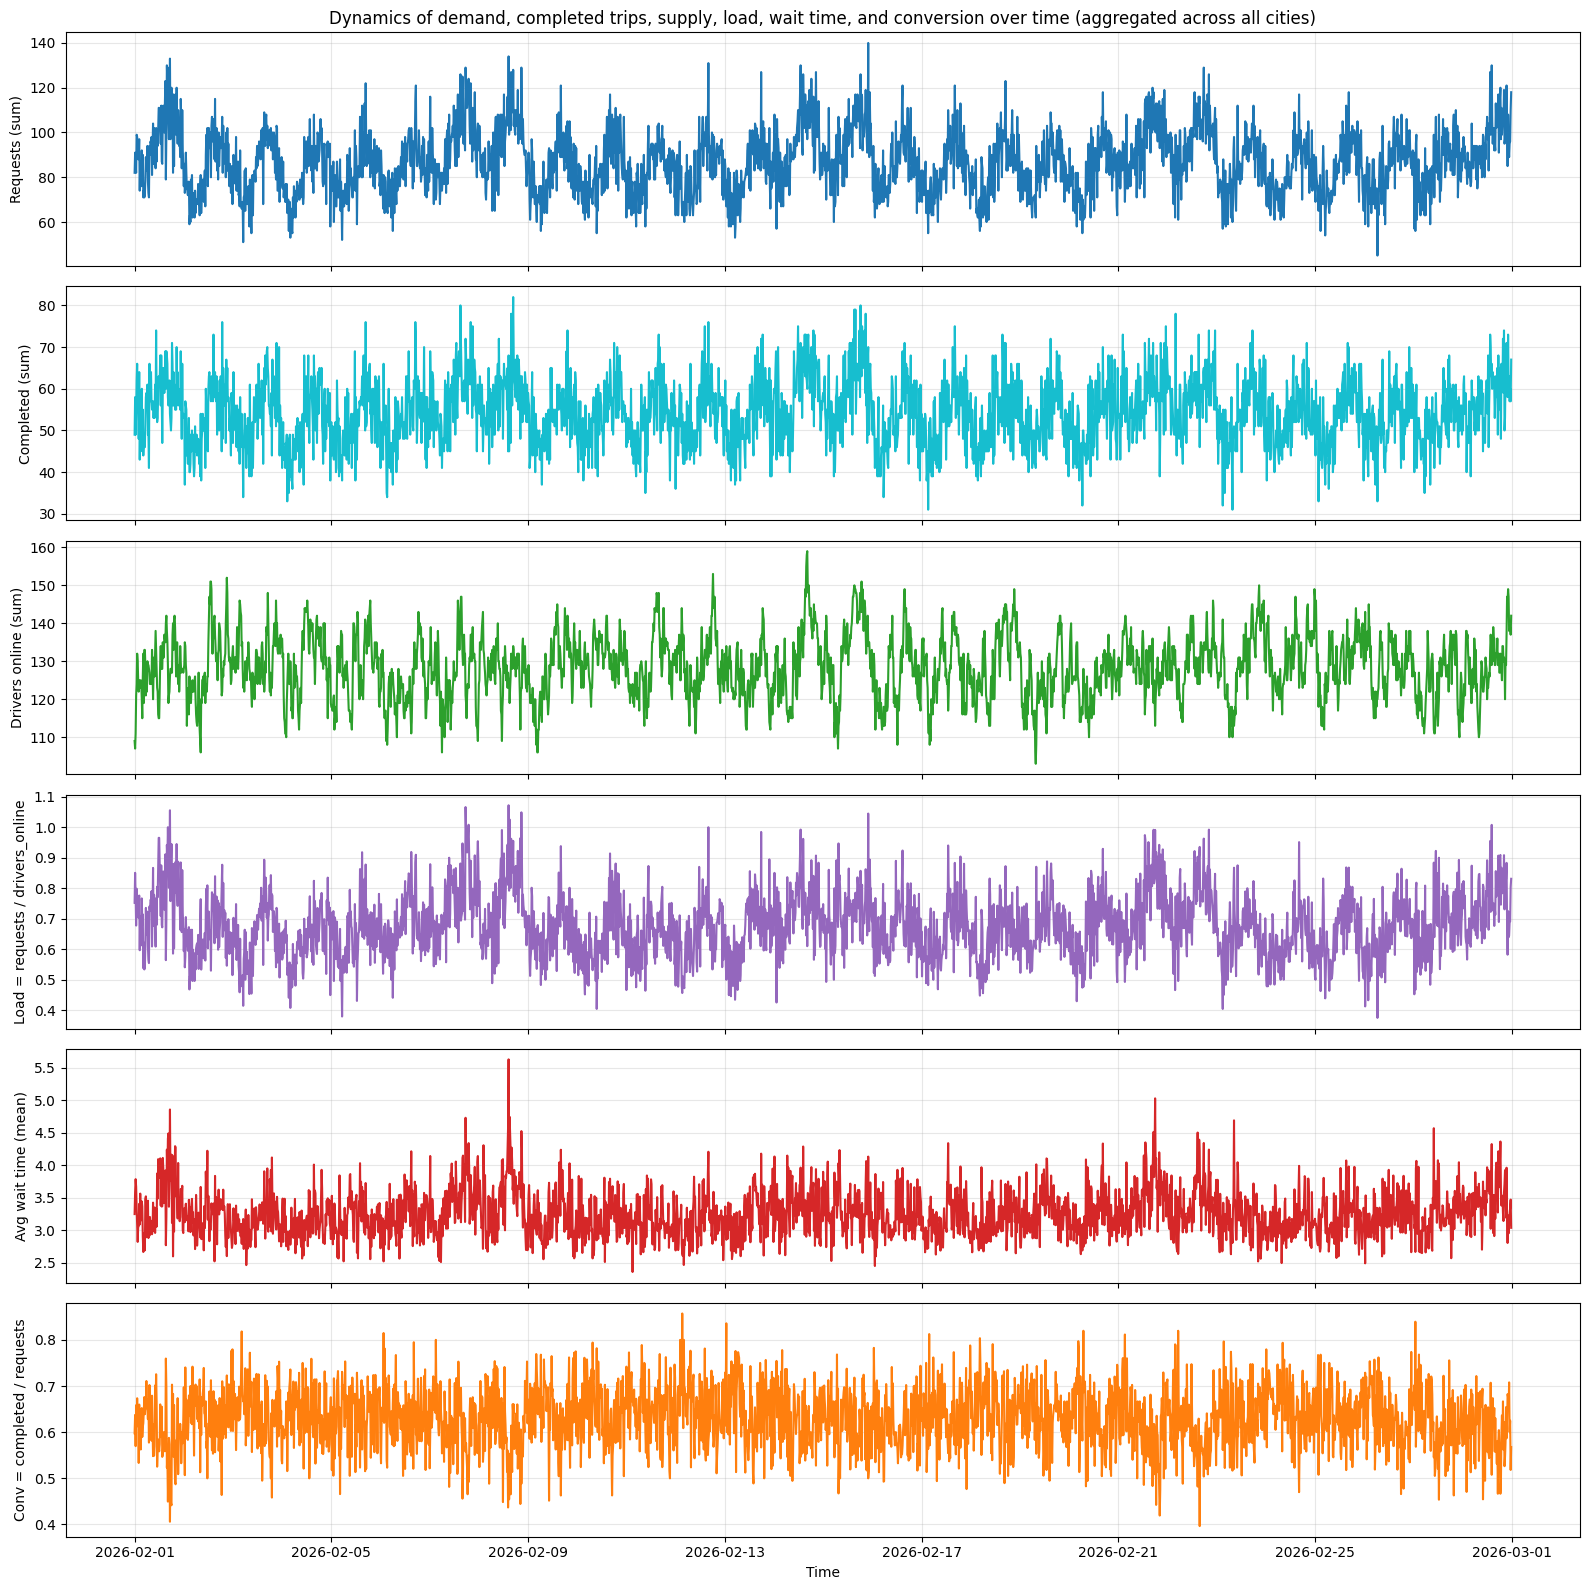

In [6]:
df_plot = (
    df_raw
    .assign(window_start=pd.to_datetime(df_raw["window_start"]))
    .groupby("window_start", as_index=False)
    .agg(
        requests=("requests", "sum"),
        completed=("completed", "sum"),
        drivers_online=("drivers_online", "sum"),
        avg_wait_time=("avg_wait_time", "mean"),
    )
    .sort_values("window_start")
)

df_plot["load"] = df_plot["requests"] / df_plot["drivers_online"].replace(0, np.nan)
df_plot["conv"] = df_plot["completed"] / df_plot["requests"].replace(0, np.nan)

fig, axes = plt.subplots(6, 1, figsize=(16, 16), sharex=True)

axes[0].plot(df_plot["window_start"], df_plot["requests"], color="tab:blue", linewidth=1.5)
axes[0].set_title("Dynamics of demand, completed trips, supply, load, wait time, and conversion over time (aggregated across all cities)")
axes[0].set_ylabel("Requests (sum)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_plot["window_start"], df_plot["completed"], color="tab:cyan", linewidth=1.5)
axes[1].set_ylabel("Completed (sum)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_plot["window_start"], df_plot["drivers_online"], color="tab:green", linewidth=1.5)
axes[2].set_ylabel("Drivers online (sum)")
axes[2].grid(True, alpha=0.3)

axes[3].plot(df_plot["window_start"], df_plot["load"], color="tab:purple", linewidth=1.5)
axes[3].set_ylabel("Load = requests / drivers_online")
axes[3].grid(True, alpha=0.3)

axes[4].plot(df_plot["window_start"], df_plot["avg_wait_time"], color="tab:red", linewidth=1.5)
axes[4].set_ylabel("Avg wait time (mean)")
axes[4].grid(True, alpha=0.3)

axes[5].plot(df_plot["window_start"], df_plot["conv"], color="tab:orange", linewidth=1.5)
axes[5].set_ylabel("Conv = completed / requests")
axes[5].set_xlabel("Time")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Average hourly profile for key metrics

Why?

This is one of the most useful plots for marketplace data:
- it shows daily seasonality
- it helps identify hours when the marketplace is overloaded
- it allows us to see where the treatment effect could potentially be most noticeable

Especially useful comparisons:
- weekdays vs weekends
- different cities on the same plot

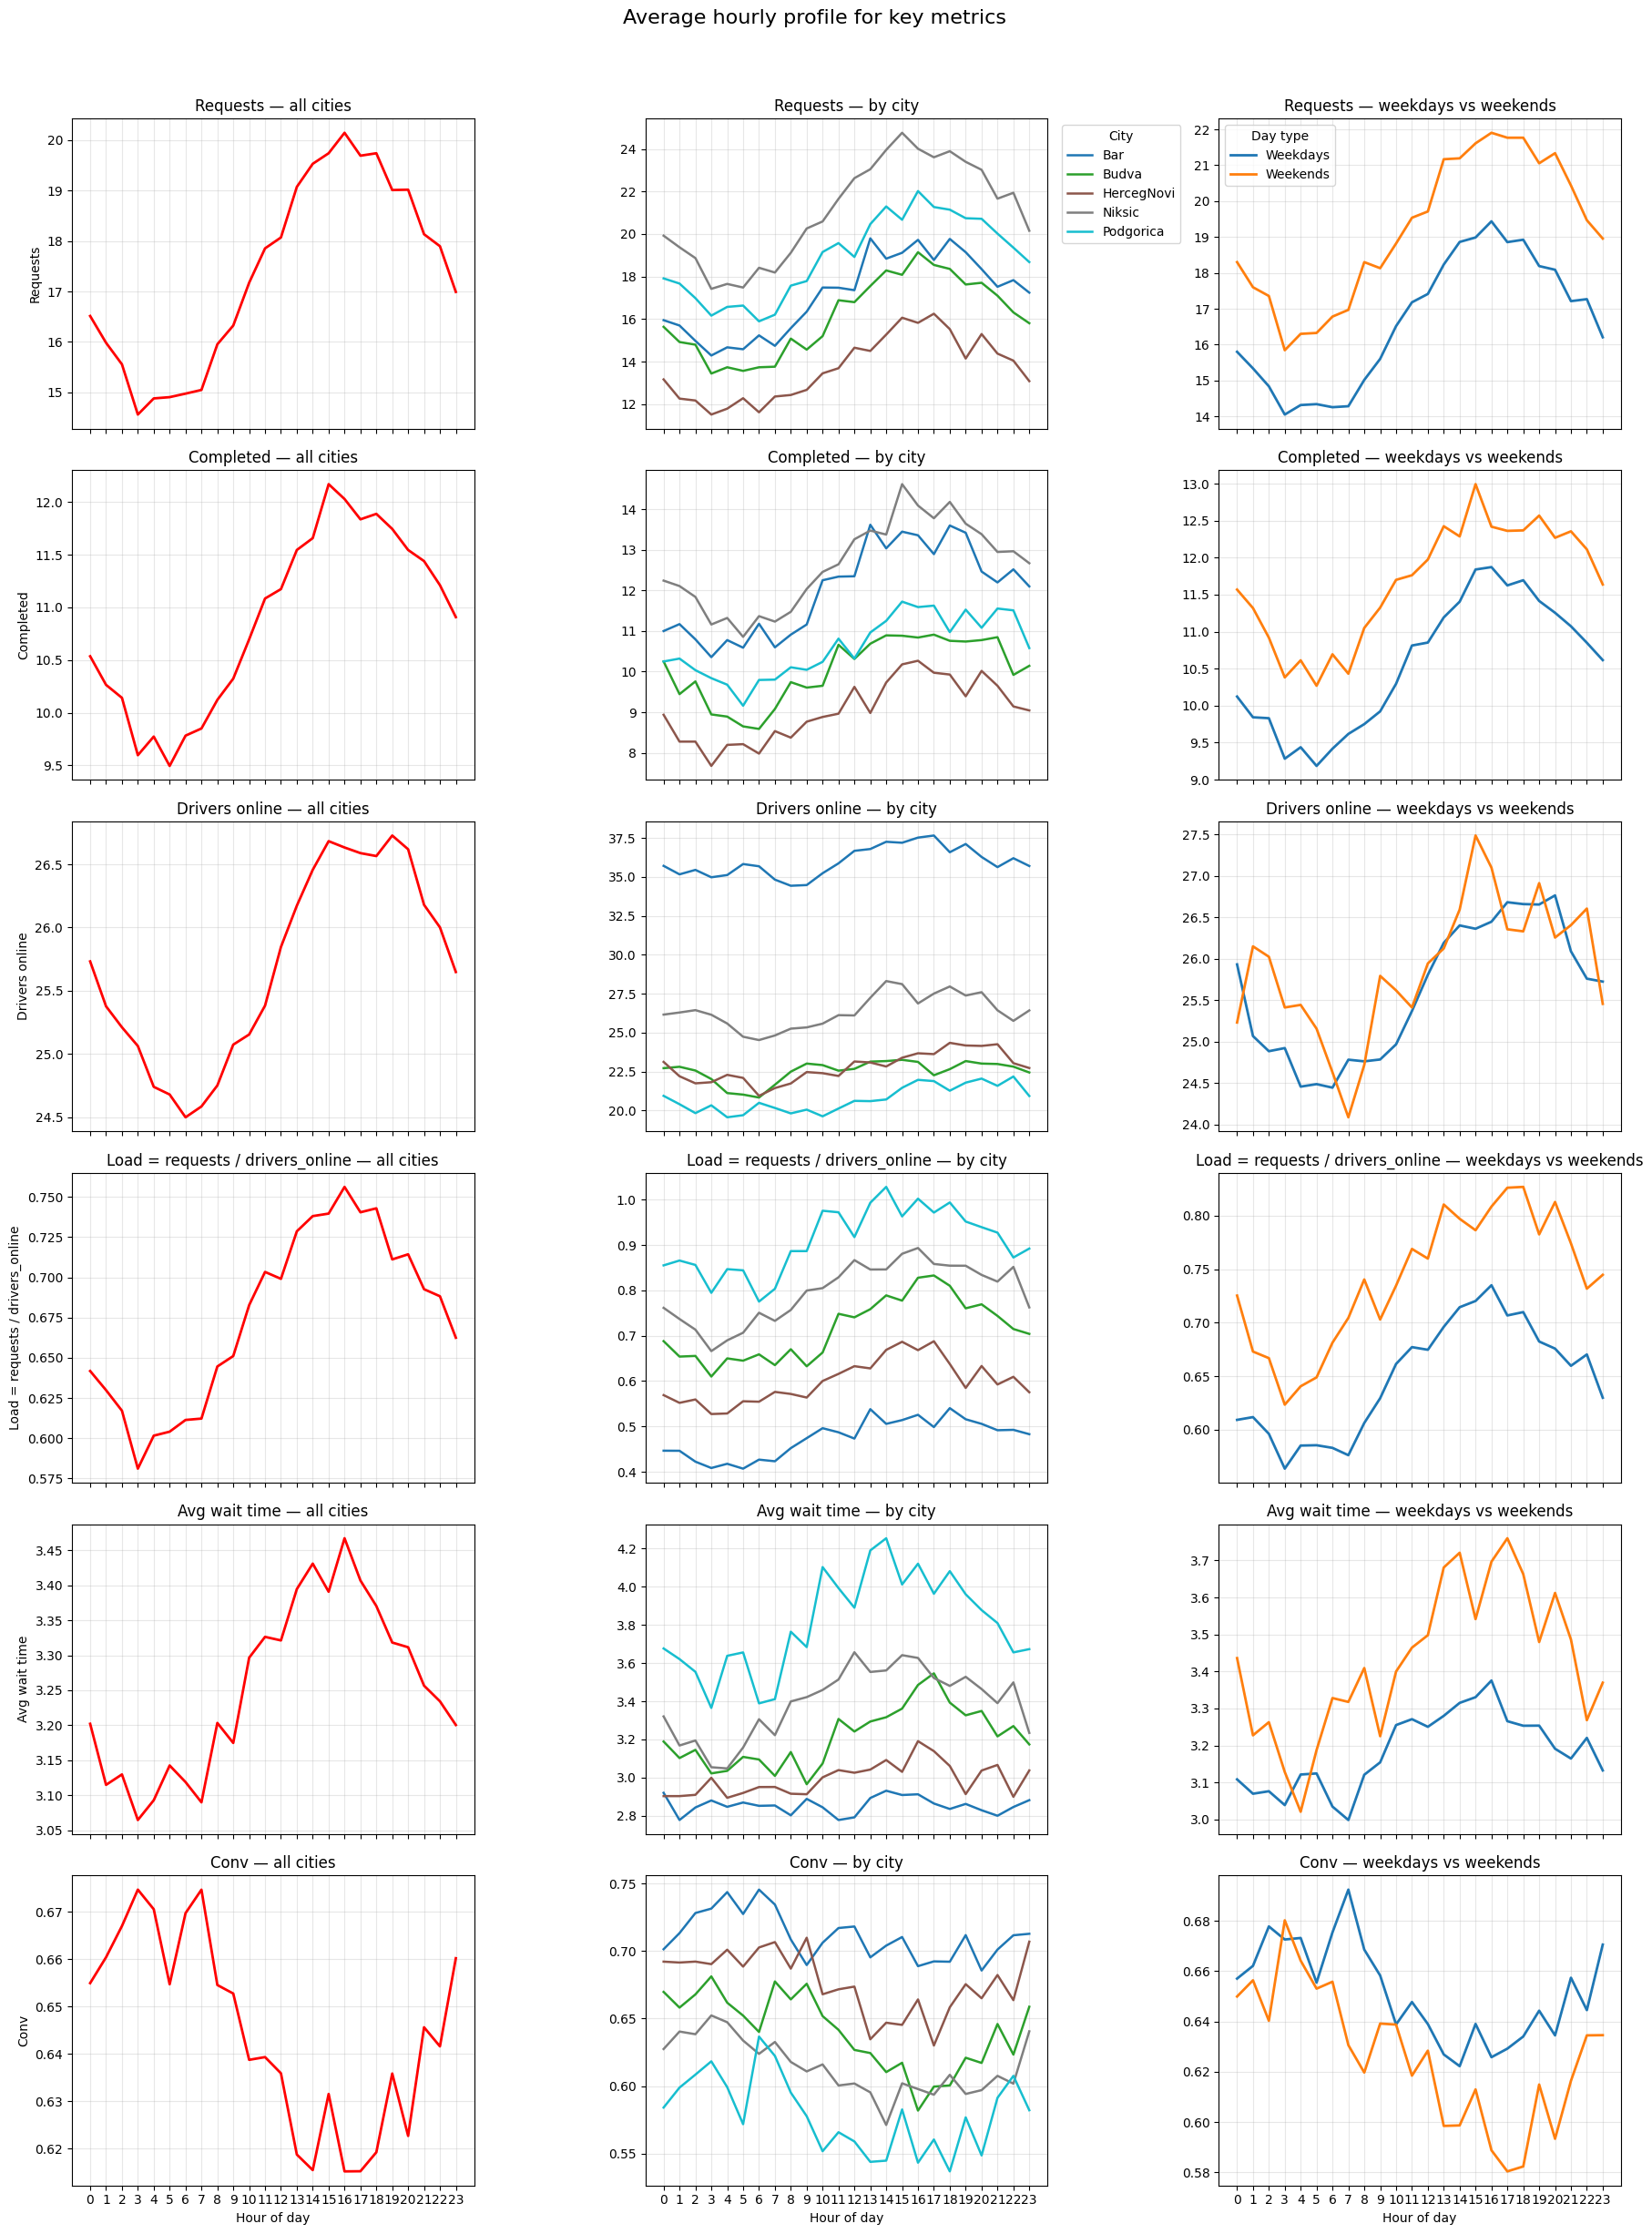

In [7]:
hourly_all = (
    df_raw
    .groupby("hour", as_index=False)
    .agg(
        requests=("requests", "mean"),
        completed=("completed", "mean"),
        drivers_online=("drivers_online", "mean"),
        avg_wait_time=("avg_wait_time", "mean"),
        conv=("conv", "mean"),
    )
    .sort_values("hour")
)
hourly_all["load"] = hourly_all["requests"] / hourly_all["drivers_online"].replace(0, np.nan)

hourly_city = (
    df_raw
    .groupby(["city", "hour"], as_index=False)
    .agg(
        requests=("requests", "mean"),
        completed=("completed", "mean"),
        drivers_online=("drivers_online", "mean"),
        avg_wait_time=("avg_wait_time", "mean"),
        conv=("conv", "mean"),
    )
    .sort_values(["city", "hour"])
)
hourly_city["load"] = hourly_city["requests"] / hourly_city["drivers_online"].replace(0, np.nan)

hourly_weekend = (
    df_raw
    .groupby(["is_weekend", "hour"], as_index=False)
    .agg(
        requests=("requests", "mean"),
        completed=("completed", "mean"),
        drivers_online=("drivers_online", "mean"),
        avg_wait_time=("avg_wait_time", "mean"),
        conv=("conv", "mean"),
    )
    .sort_values(["is_weekend", "hour"])
)
hourly_weekend["load"] = hourly_weekend["requests"] / hourly_weekend["drivers_online"].replace(0, np.nan)

metrics = ["requests", "completed", "drivers_online", "load", "avg_wait_time", "conv"]
titles = {
    "requests": "Requests",
    "completed": "Completed",
    "drivers_online": "Drivers online",
    "load": "Load = requests / drivers_online",
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
}

fig, axes = plt.subplots(len(metrics), 3, figsize=(18, 24), sharex=True)

cities = sorted(hourly_city["city"].unique())
city_cmap = plt.get_cmap("tab10", len(cities))
city_colors = {city: city_cmap(i) for i, city in enumerate(cities)}

weekend_labels = {0: "Weekdays", 1: "Weekends"}
weekend_colors = {0: "tab:blue", 1: "tab:orange"}

for i, metric in enumerate(metrics):
    ax = axes[i, 0]
    ax.plot(hourly_all["hour"], hourly_all[metric], color="red", linewidth=2)
    ax.set_title(f"{titles[metric]} — all cities")
    ax.set_ylabel(titles[metric])
    ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    for city in cities:
        part = hourly_city[hourly_city["city"] == city]
        ax.plot(part["hour"], part[metric], label=city, linewidth=1.8, color=city_colors[city])
    ax.set_title(f"{titles[metric]} — by city")
    ax.grid(True, alpha=0.3)

    ax = axes[i, 2]
    for flag in [0, 1]:
        part = hourly_weekend[hourly_weekend["is_weekend"] == flag]
        ax.plot(
            part["hour"],
            part[metric],
            label=weekend_labels[flag],
            linewidth=2,
            color=weekend_colors[flag],
        )
    ax.set_title(f"{titles[metric]} — weekdays vs weekends")
    ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(24))

axes[0, 1].legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0, 2].legend(title="Day type")

fig.suptitle("Average hourly profile for key metrics", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Boxplot / violinplot of metrics across cities

Why?
- to understand how cities differ in scale
- to identify where variability is higher
- to see where wait time is systematically higher
- to identify where conversion is worse

What can be understood quickly?
For example:
- one city may have high demand but weak supply
- another may have consistently low `avg_wait_time`
- a third may be the “noisiest” in terms of `conv`

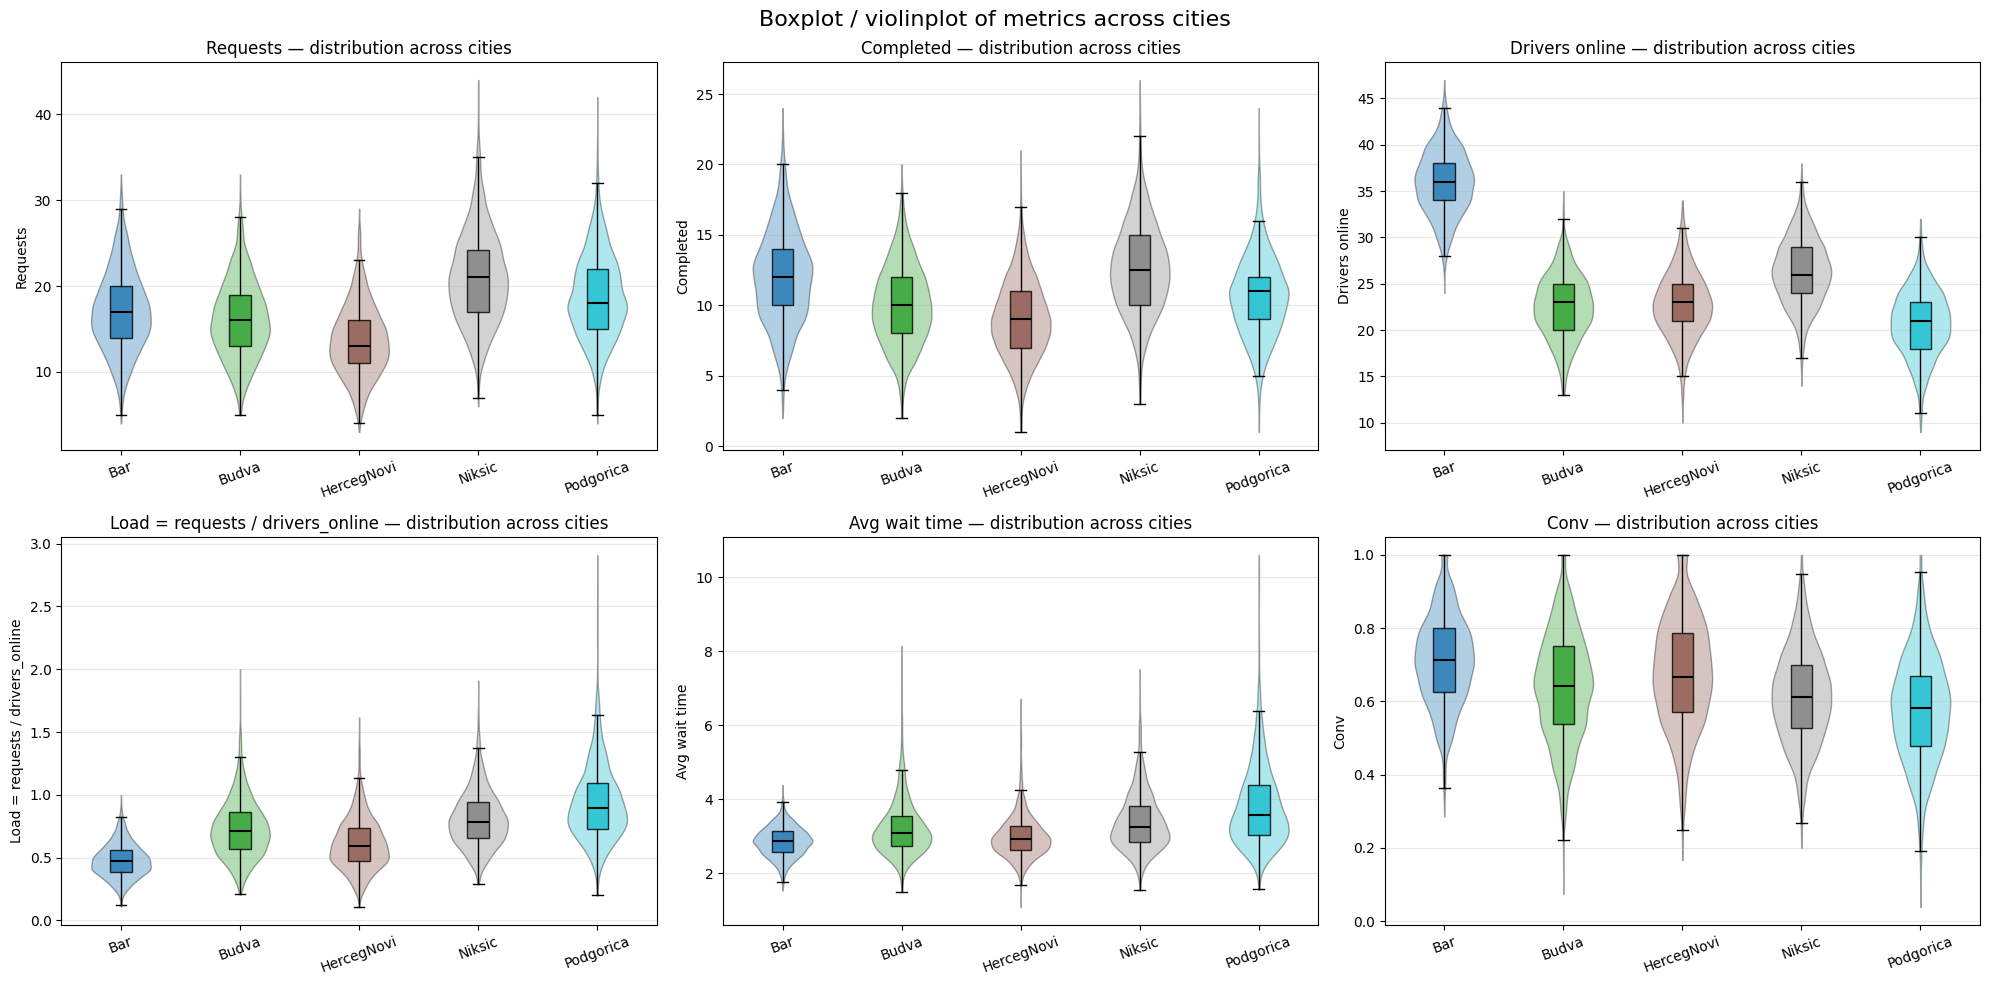

In [8]:
df_plot_city = df_raw.copy()
df_plot_city["load"] = df_plot_city["requests"] / df_plot_city["drivers_online"].replace(0, np.nan)

metrics = ["requests", "completed", "drivers_online", "load", "avg_wait_time", "conv"]
titles = {
    "requests": "Requests",
    "completed": "Completed",
    "drivers_online": "Drivers online",
    "load": "Load = requests / drivers_online",
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
}

cities = sorted(df_raw["city"].unique())
city_positions = np.arange(1, len(cities) + 1)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    data_by_city = [df_plot_city.loc[df_plot_city["city"] == city, metric].dropna().values for city in cities]

    violin = ax.violinplot(
        data_by_city,
        positions=city_positions,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body, city in zip(violin["bodies"], cities):
        body.set_facecolor(city_colors.get(city, "tab:blue"))
        body.set_edgecolor("black")
        body.set_alpha(0.35)

    box = ax.boxplot(
        data_by_city,
        positions=city_positions,
        widths=0.18,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"color": "black", "linewidth": 1},
        capprops={"color": "black", "linewidth": 1},
        boxprops={"edgecolor": "black", "linewidth": 1},
    )
    for patch, city in zip(box["boxes"], cities):
        patch.set_facecolor(city_colors.get(city, "tab:blue"))
        patch.set_alpha(0.8)

    ax.set_title(f"{titles[metric]} — distribution across cities")
    ax.set_xticks(city_positions)
    ax.set_xticklabels(cities, rotation=20)
    ax.set_ylabel(titles[metric])
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Boxplot / violinplot of metrics across cities", fontsize=16)
plt.tight_layout()
plt.show()

## Comparison of treatment vs control across key metrics

Why?

This is the most direct visual answer to the question: “Does the treatment have any effect at all?”

Important
It is important to look not only at the full sample, but also:
- by city
- by hour of day
- by market load level

Otherwise, it is easy to miss an effect that appears only under “heavy-load” conditions.

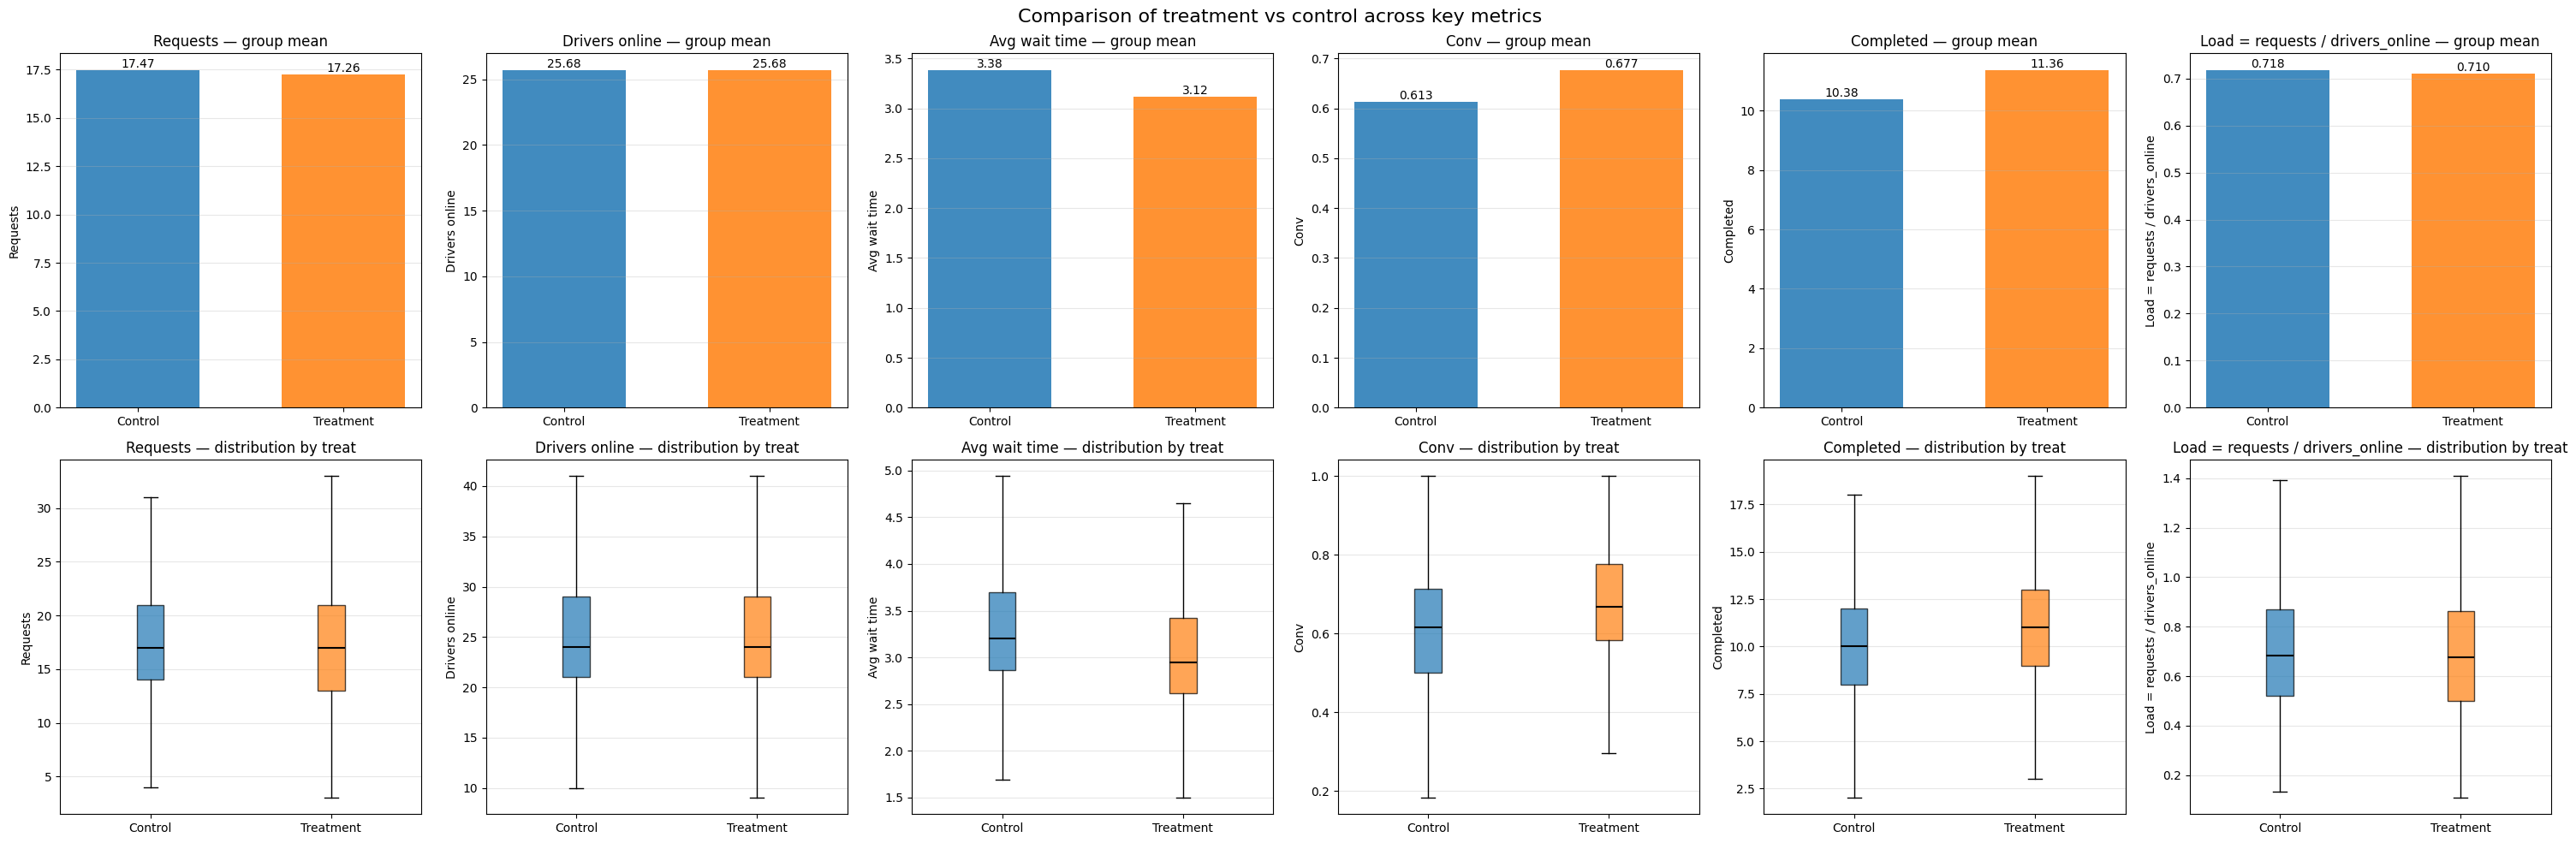

In [9]:
df_treat_plot = df_raw.copy()
df_treat_plot["load"] = df_treat_plot["requests"] / df_treat_plot["drivers_online"].replace(0, np.nan)

metrics = ["requests", "drivers_online", "avg_wait_time", "conv", "completed", "load"]
titles = {
    "requests": "Requests",
    "drivers_online": "Drivers online",
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
    "completed": "Completed",
    "load": "Load = requests / drivers_online",
}
treat_labels = {0: "Control", 1: "Treatment"}
treat_colors = {0: "tab:blue", 1: "tab:orange"}

summary_treat = (
    df_treat_plot
    .groupby("treat", as_index=False)[metrics]
    .mean()
    .sort_values("treat")
)

fig, axes = plt.subplots(2, 6, figsize=(30, 10))
positions = [0, 1]

for i, metric in enumerate(metrics):
    ax = axes[0, i]
    vals = summary_treat[metric].values
    ax.bar(
        summary_treat["treat"].astype(int).values,
        vals,
        color=[treat_colors[t] for t in summary_treat["treat"].astype(int).values],
        width=0.6,
        alpha=0.85,
    )
    ax.set_title(f"{titles[metric]} — group mean")
    ax.set_xticks(positions)
    ax.set_xticklabels([treat_labels[p] for p in positions])
    ax.set_ylabel(titles[metric])
    ax.grid(True, axis="y", alpha=0.3)

    for x, y in zip(summary_treat["treat"].astype(int).values, vals):
        if metric in ["conv", "load"]:
            label = f"{y:.3f}"
        else:
            label = f"{y:.2f}"
        ax.text(x, y, label, ha="center", va="bottom")

    ax = axes[1, i]
    data = [
        df_treat_plot.loc[df_treat_plot["treat"] == 0, metric].dropna().values,
        df_treat_plot.loc[df_treat_plot["treat"] == 1, metric].dropna().values,
    ]
    box = ax.boxplot(
        data,
        tick_labels=[treat_labels[0], treat_labels[1]],
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"color": "black", "linewidth": 1},
        capprops={"color": "black", "linewidth": 1},
        boxprops={"edgecolor": "black", "linewidth": 1},
    )
    for patch, t in zip(box["boxes"], positions):
        patch.set_facecolor(treat_colors[t])
        patch.set_alpha(0.7)

    ax.set_title(f"{titles[metric]} — distribution by treat")
    ax.set_ylabel(titles[metric])
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Comparison of treatment vs control across key metrics", fontsize=16)
plt.tight_layout()
plt.show()

## Treatment effect breakdown

We plot the same metrics (`avg_wait_time`, `conv`, `completed`) broken down:
- by city
- by hour of day
- by market load level (`requests / drivers_online`)

In [10]:
metrics = ["avg_wait_time", "conv", "completed"]
titles = {
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
    "completed": "Completed",
}
treat_labels = {0: "Control", 1: "Treatment"}
treat_colors = {0: "tab:blue", 1: "tab:orange"}

df_effect = df_raw.copy()
df_effect["market_load"] = df_effect["requests"] / df_effect["drivers_online"].replace(0, np.nan)
df_effect["market_load_level"] = pd.qcut(
    df_effect["market_load"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

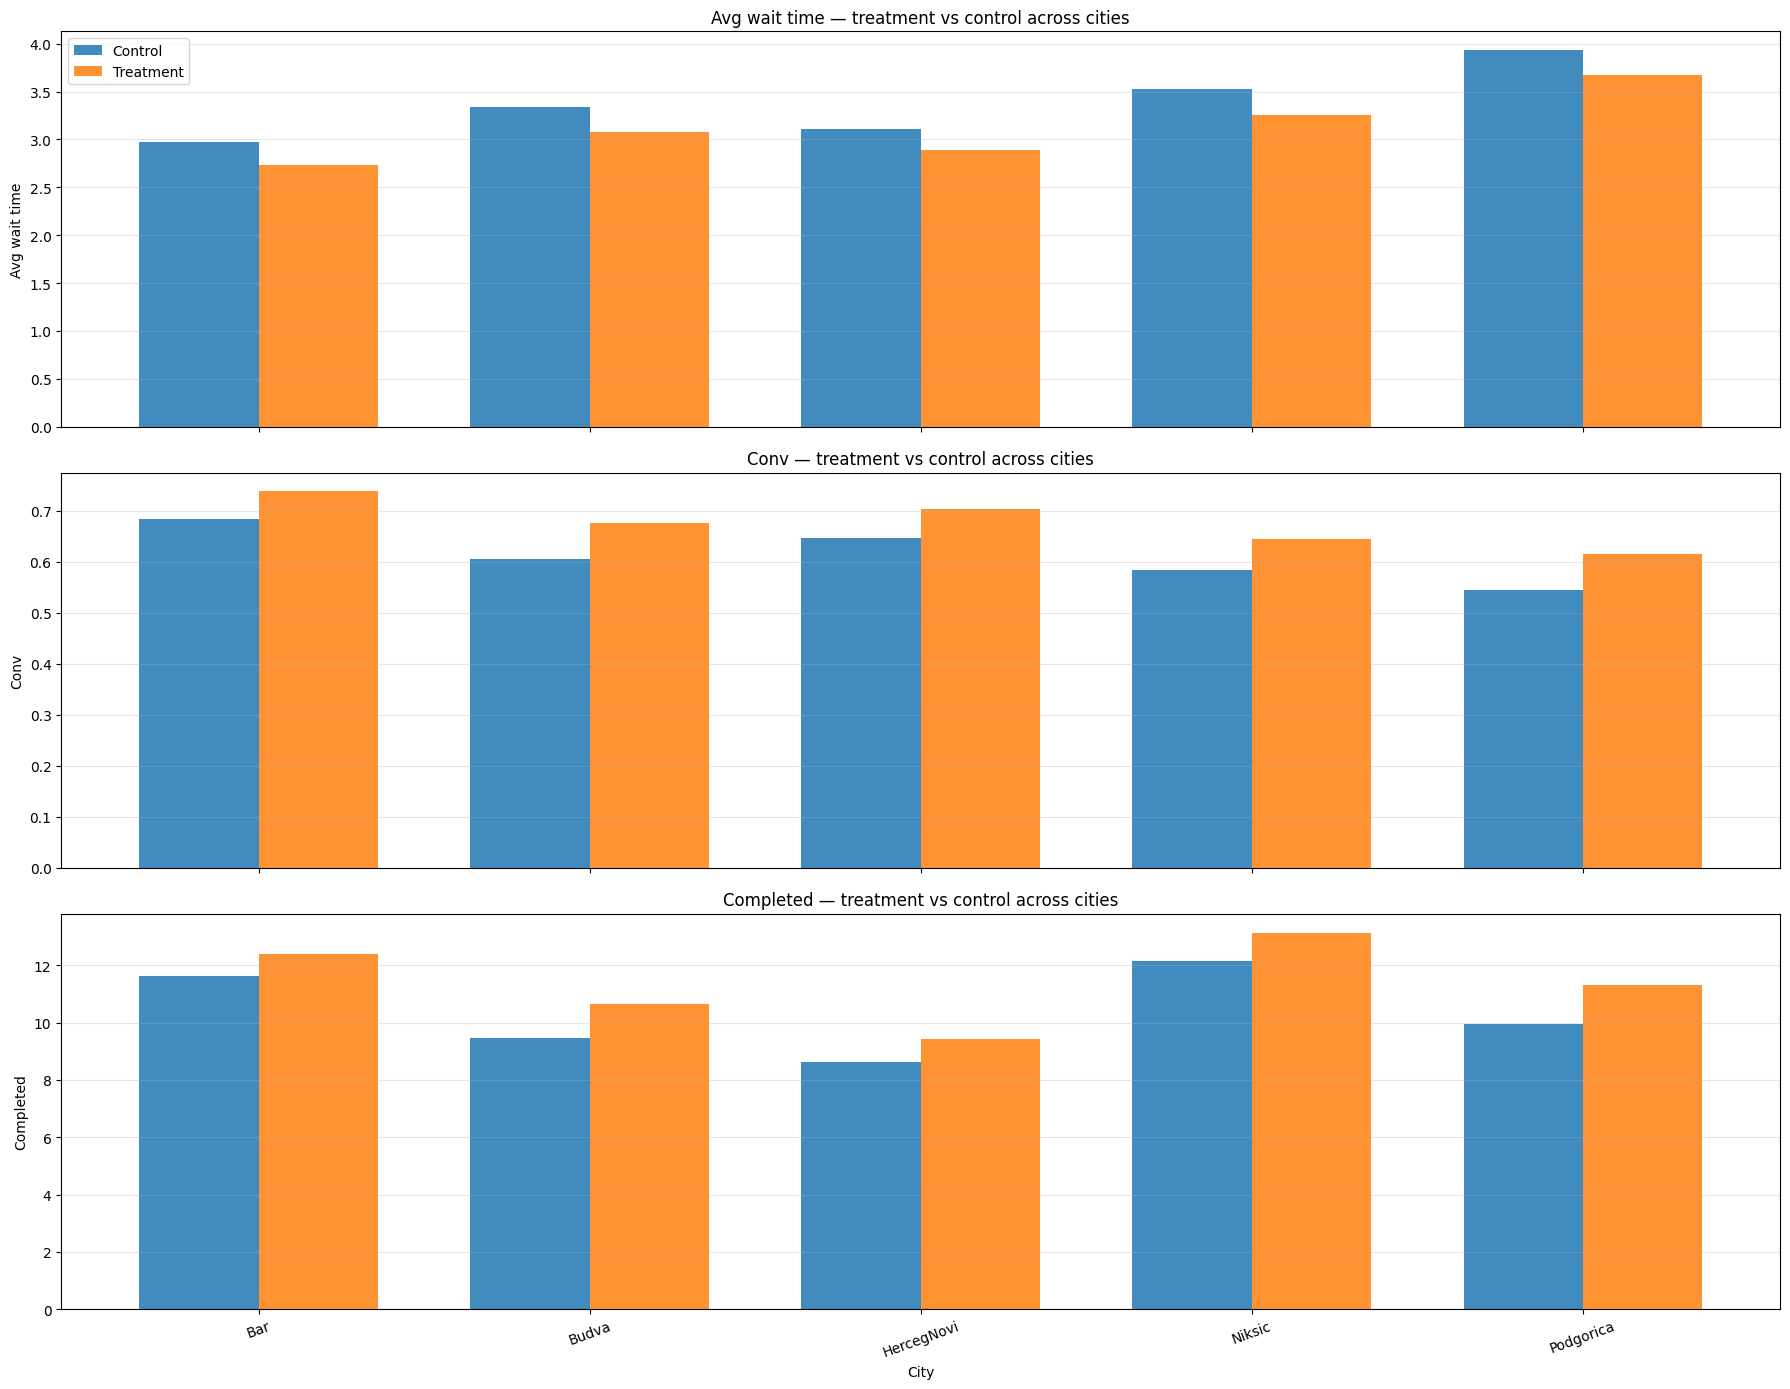

In [11]:
plot_metrics = metrics
plot_titles = titles

summary_city = (
    df_effect
    .groupby(["city", "treat"], as_index=False)[plot_metrics]
    .mean()
    .sort_values(["city", "treat"])
)

fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(18, 14), sharex=True)

cities = sorted(summary_city["city"].unique())
x = np.arange(len(cities))
width = 0.36

for i, metric in enumerate(plot_metrics):
    ax = axes[i]
    control = (
        summary_city[summary_city["treat"] == 0]
        .set_index("city")
        .reindex(cities)[metric]
        .values
    )
    treatment = (
        summary_city[summary_city["treat"] == 1]
        .set_index("city")
        .reindex(cities)[metric]
        .values
    )

    ax.bar(x - width / 2, control, width=width, color=treat_colors[0], label=treat_labels[0], alpha=0.85)
    ax.bar(x + width / 2, treatment, width=width, color=treat_colors[1], label=treat_labels[1], alpha=0.85)

    ax.set_title(f"{plot_titles[metric]} — treatment vs control across cities")
    ax.set_ylabel(plot_titles[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=20)
    ax.grid(True, axis="y", alpha=0.3)

axes[0].legend()
axes[-1].set_xlabel("City")
plt.tight_layout()
plt.show()

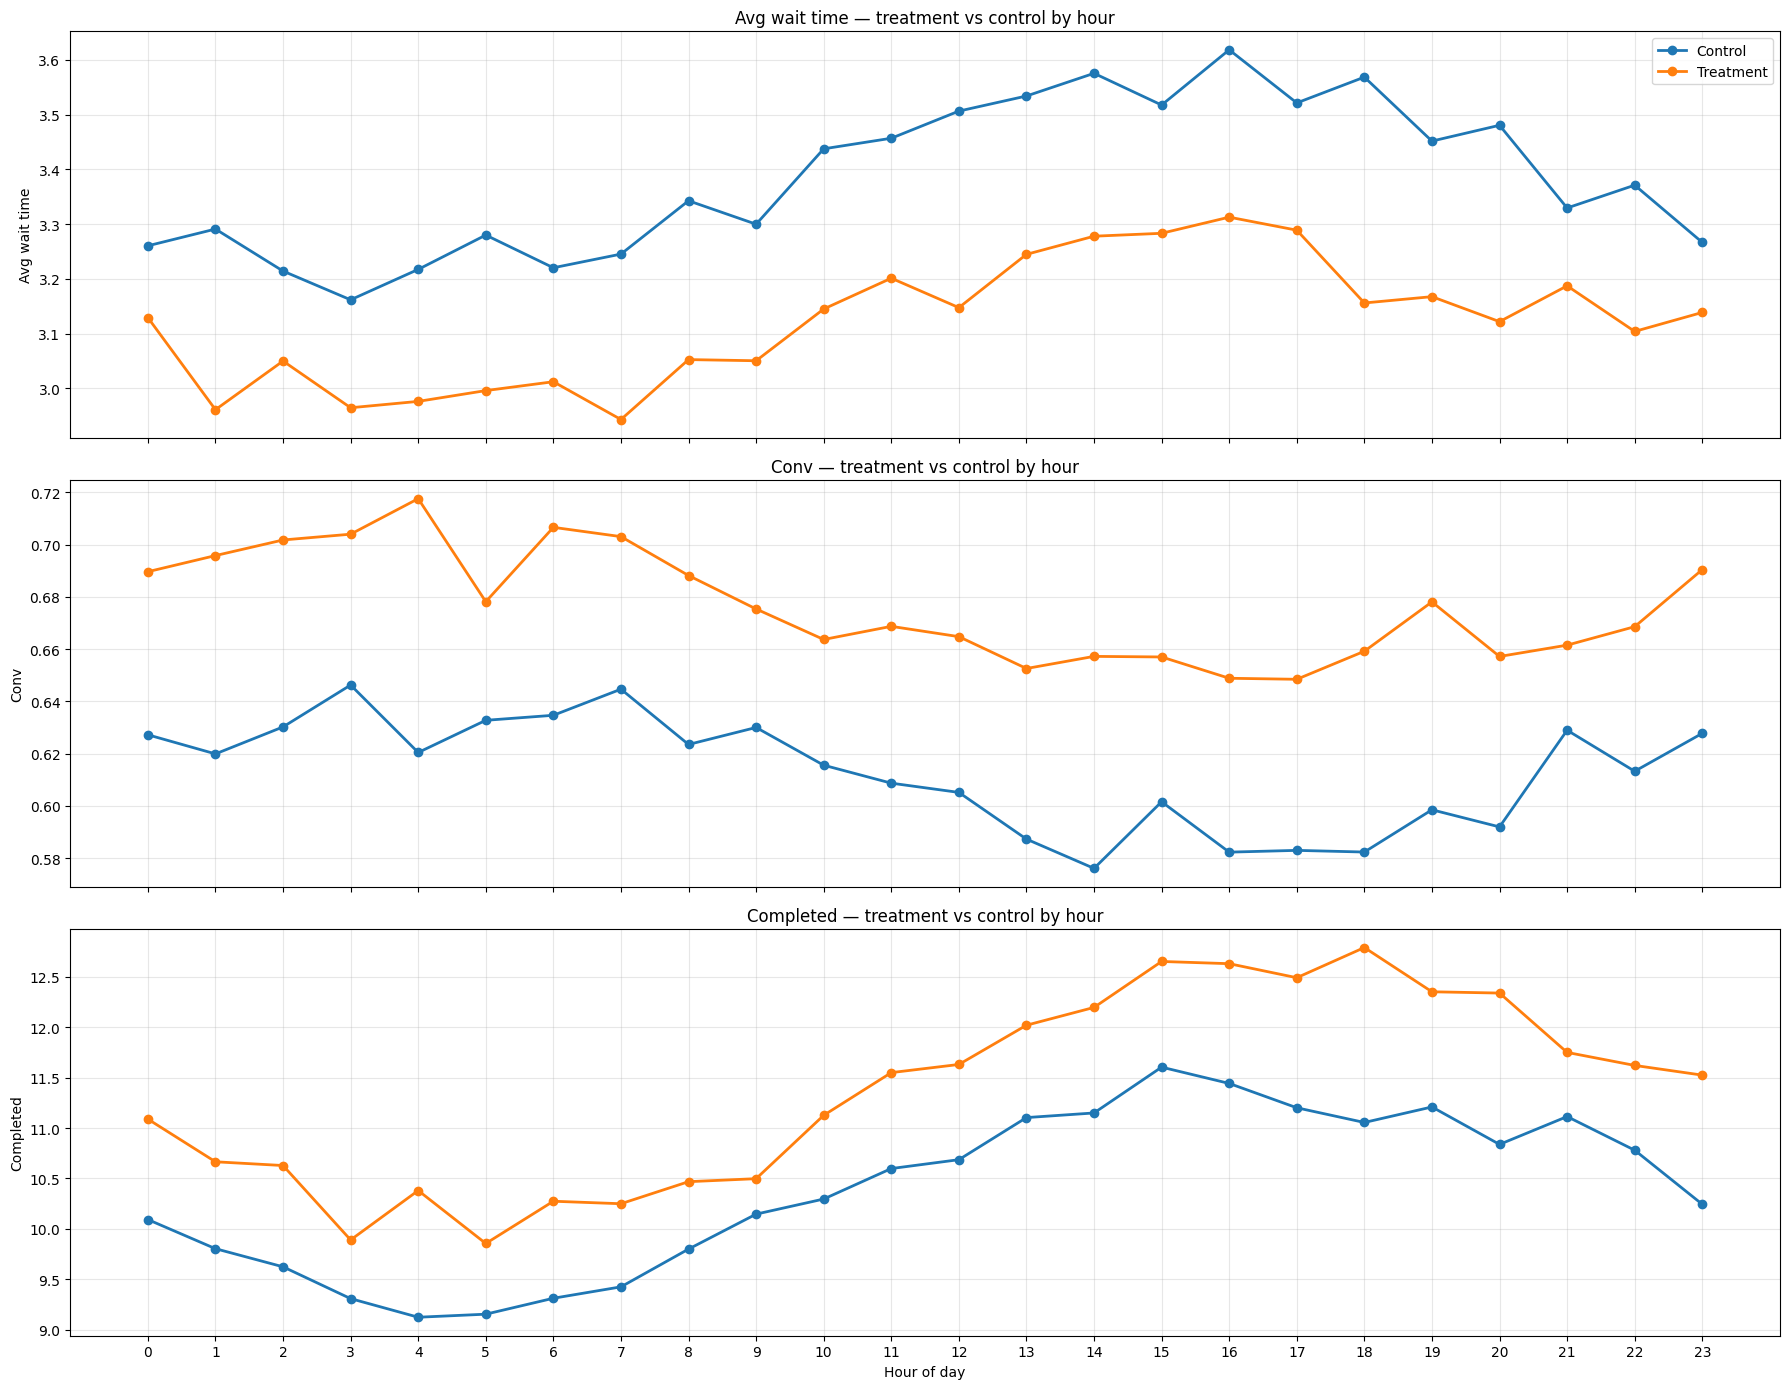

In [12]:
plot_metrics = metrics
plot_titles = titles

summary_hour = (
    df_effect
    .groupby(["hour", "treat"], as_index=False)[plot_metrics]
    .mean()
    .sort_values(["hour", "treat"])
)

fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(18, 14), sharex=True)

for i, metric in enumerate(plot_metrics):
    ax = axes[i]
    for treat in [0, 1]:
        part = summary_hour[summary_hour["treat"] == treat]
        ax.plot(
            part["hour"],
            part[metric],
            marker="o",
            linewidth=2,
            color=treat_colors[treat],
            label=treat_labels[treat],
        )

    ax.set_title(f"{plot_titles[metric]} — treatment vs control by hour")
    ax.set_ylabel(plot_titles[metric])
    ax.set_xticks(range(24))
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[-1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

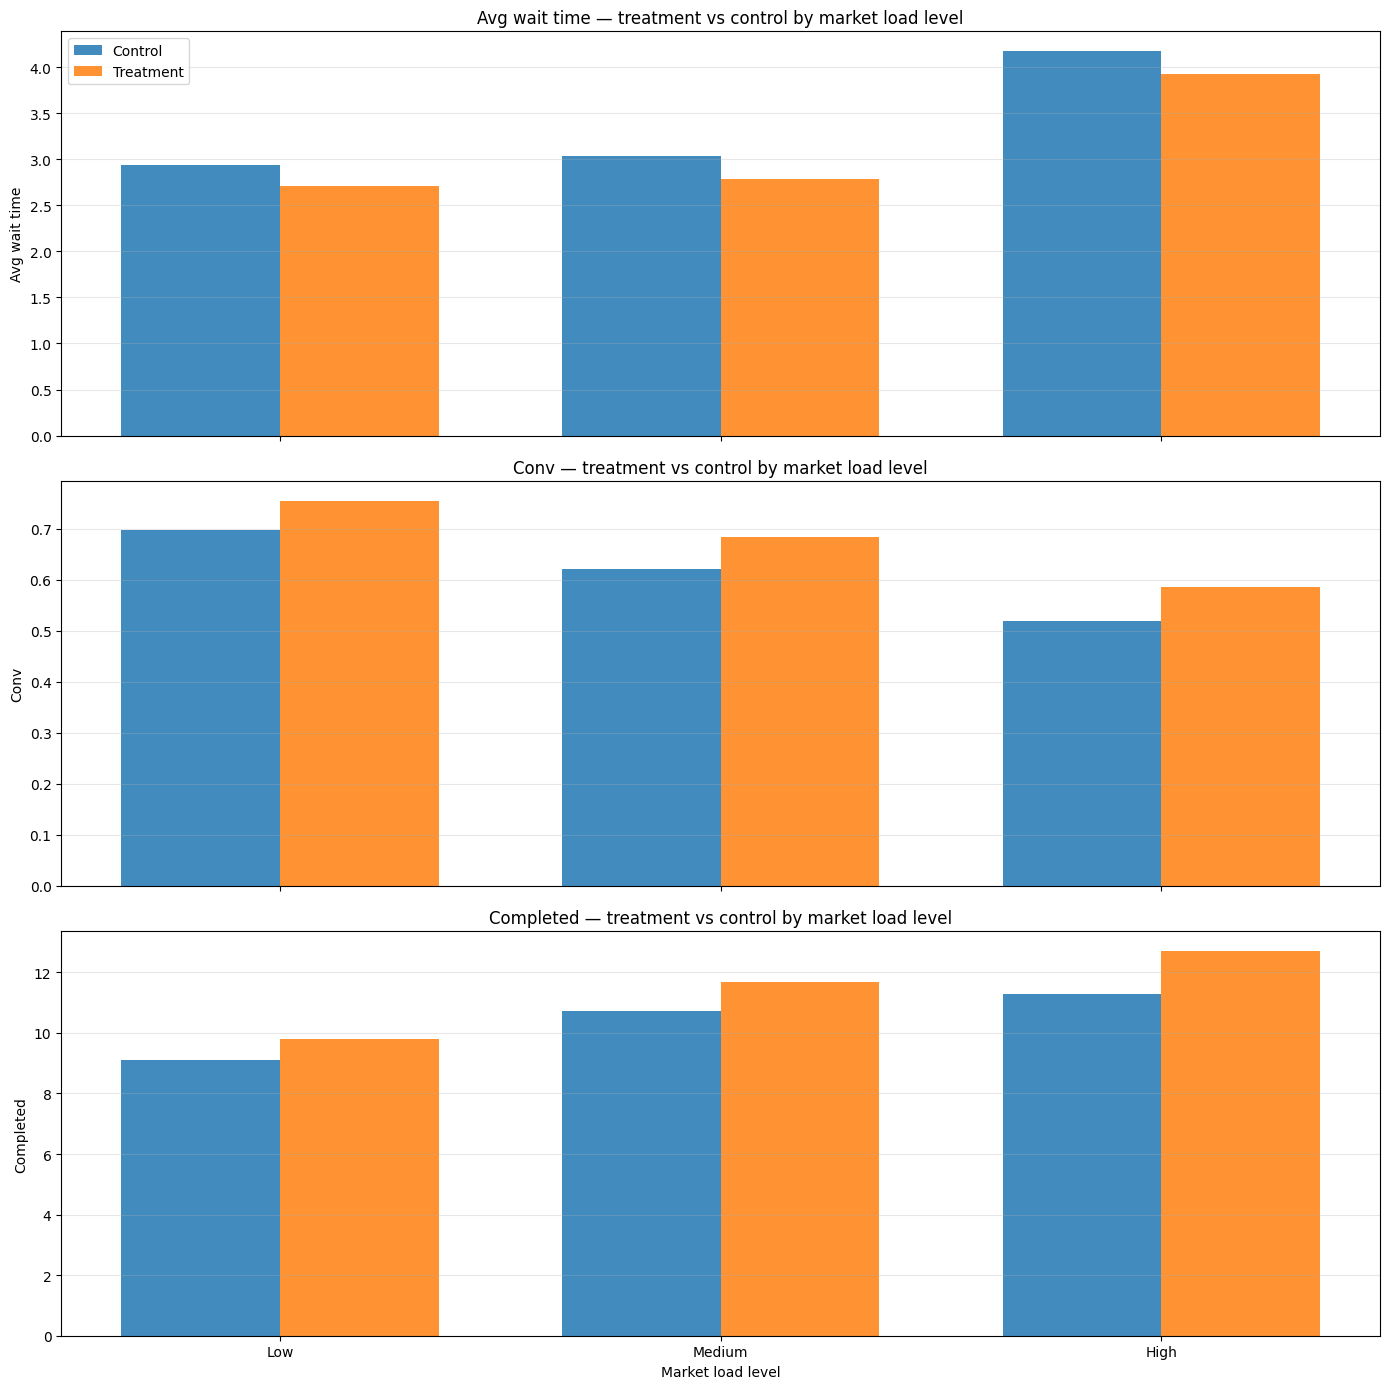

In [13]:
plot_metrics = metrics
plot_titles = titles

summary_load = (
    df_effect
    .dropna(subset=["market_load_level"])
    .groupby(["market_load_level", "treat"], as_index=False, observed=False)[plot_metrics]
    .mean()
)

load_order = ["Low", "Medium", "High"]
summary_load["market_load_level"] = pd.Categorical(
    summary_load["market_load_level"],
    categories=load_order,
    ordered=True,
)
summary_load = summary_load.sort_values(["market_load_level", "treat"])

fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(14, 14), sharex=True)

x = np.arange(len(load_order))
width = 0.36

for i, metric in enumerate(plot_metrics):
    ax = axes[i]
    control = (
        summary_load[summary_load["treat"] == 0]
        .set_index("market_load_level")
        .reindex(load_order)[metric]
        .values
    )
    treatment = (
        summary_load[summary_load["treat"] == 1]
        .set_index("market_load_level")
        .reindex(load_order)[metric]
        .values
    )

    ax.bar(x - width / 2, control, width=width, color=treat_colors[0], label=treat_labels[0], alpha=0.85)
    ax.bar(x + width / 2, treatment, width=width, color=treat_colors[1], label=treat_labels[1], alpha=0.85)

    ax.set_title(f"{plot_titles[metric]} — treatment vs control by market load level")
    ax.set_ylabel(plot_titles[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(load_order)
    ax.grid(True, axis="y", alpha=0.3)

axes[0].legend()
axes[-1].set_xlabel("Market load level")
plt.tight_layout()
plt.show()

# Treatment effect under different market load levels

This is probably the most important analytical visualization.

Why?

If the treatment is designed to help under supply shortage conditions, then its effect should appear not in the overall average, but specifically under high market load.

What should we expect?
Under low load, the lines may be almost identical.

Under high load:
- `avg_wait_time` should be lower for the treatment group
- `conv` should be higher for the treatment group

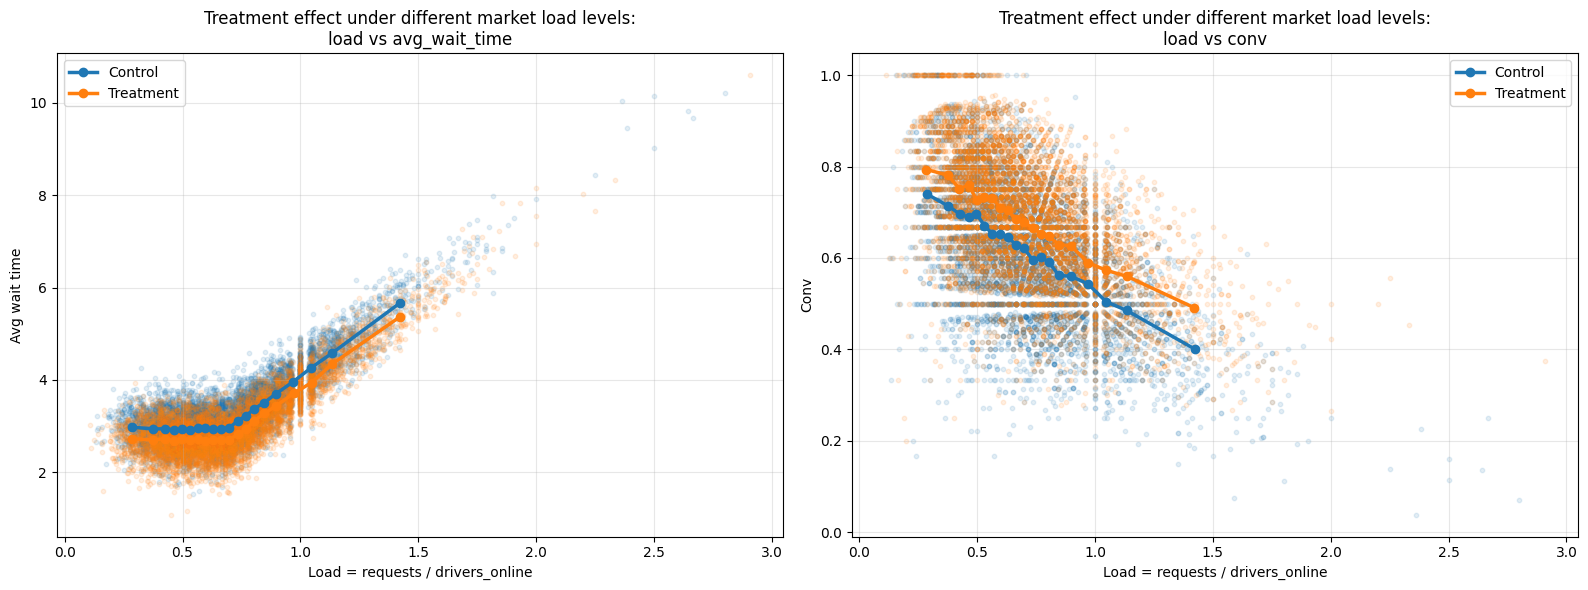

In [14]:
df_load_plot = df_raw.copy()
df_load_plot["load"] = df_load_plot["requests"] / df_load_plot["drivers_online"].replace(0, np.nan)
df_load_plot = df_load_plot.dropna(subset=["load", "avg_wait_time", "conv"])

n_bins = 20
df_load_plot["load_bin"] = pd.qcut(df_load_plot["load"], q=n_bins, duplicates="drop")

binned = (
    df_load_plot
    .groupby(["treat", "load_bin"], observed=False, as_index=False)
    .agg(
        load=("load", "mean"),
        avg_wait_time=("avg_wait_time", "mean"),
        conv=("conv", "mean"),
        n=("load", "size"),
    )
    .sort_values(["treat", "load"])
)

treat_labels = {0: "Control", 1: "Treatment"}
treat_colors = {0: "tab:blue", 1: "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for treat in [0, 1]:
    raw_part = df_load_plot[df_load_plot["treat"] == treat]
    bin_part = binned[binned["treat"] == treat]

    axes[0].scatter(
        raw_part["load"],
        raw_part["avg_wait_time"],
        s=10,
        alpha=0.12,
        color=treat_colors[treat],
    )
    axes[0].plot(
        bin_part["load"],
        bin_part["avg_wait_time"],
        marker="o",
        linewidth=2.5,
        color=treat_colors[treat],
        label=treat_labels[treat],
    )

    axes[1].scatter(
        raw_part["load"],
        raw_part["conv"],
        s=10,
        alpha=0.12,
        color=treat_colors[treat],
    )
    axes[1].plot(
        bin_part["load"],
        bin_part["conv"],
        marker="o",
        linewidth=2.5,
        color=treat_colors[treat],
        label=treat_labels[treat],
    )

axes[0].set_title("Treatment effect under different market load levels:\nload vs avg_wait_time")
axes[0].set_xlabel("Load = requests / drivers_online")
axes[0].set_ylabel("Avg wait time")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Treatment effect under different market load levels:\nload vs conv")
axes[1].set_xlabel("Load = requests / drivers_online")
axes[1].set_ylabel("Conv")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# Exploratory data analysis (continue)

## Heatmap by hour and day of week

Why?

- to identify days and hours when the marketplace “struggles”
- to detect the heaviest time windows
- to identify where the treatment could be especially useful

When is it especially useful?
When you want to quickly show the business:
“these are our problematic periods.”

A heatmap is usually easier to understand than a regression model.

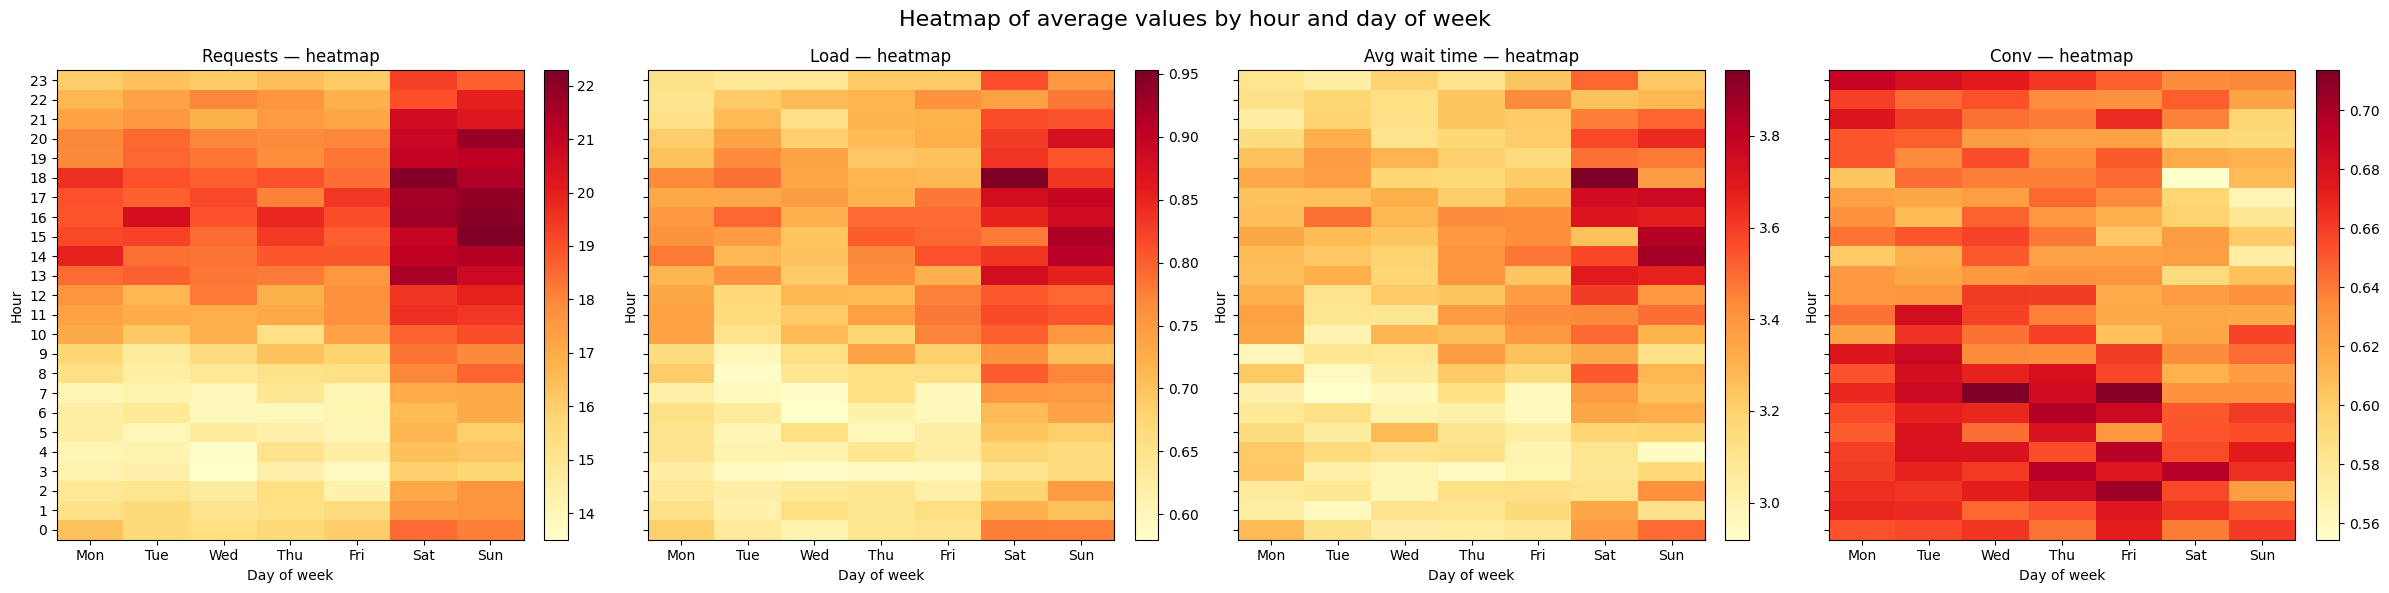

In [15]:
heatmap_metrics = ["requests", "load", "avg_wait_time", "conv"]
heatmap_titles = {
    "requests": "Requests",
    "load": "Load",
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
}
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

df_heatmap = df_raw.copy()
df_heatmap["load"] = df_heatmap["requests"] / df_heatmap["drivers_online"].replace(0, np.nan)

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)

for ax, metric in zip(axes, heatmap_metrics):
    heatmap_data = (
        df_heatmap
        .groupby(["hour", "dow"], as_index=False)[metric]
        .mean()
        .pivot(index="hour", columns="dow", values=metric)
        .reindex(index=range(24), columns=range(7))
    )

    im = ax.imshow(heatmap_data.values, aspect="auto", origin="lower", cmap="YlOrRd")
    ax.set_title(f"{heatmap_titles[metric]} — heatmap")
    ax.set_xlabel("Day of week")
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_labels, rotation=0)
    ax.set_yticks(range(24))
    ax.set_yticklabels(range(24))
    ax.set_ylabel("Hour")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Heatmap of average values by hour and day of week", fontsize=16)
plt.tight_layout()
plt.show()

## Scatter: demand vs supply

Why?

It shows the core mechanics of the marketplace:
- where the market is balanced
- where supply shortage occurs
- how this is related to service quality

What can we observe?
- in regions where `requests` are much higher than `drivers_online`, wait time should increase and conversion should decrease
- treatment may visually shift points toward “better” outcomes

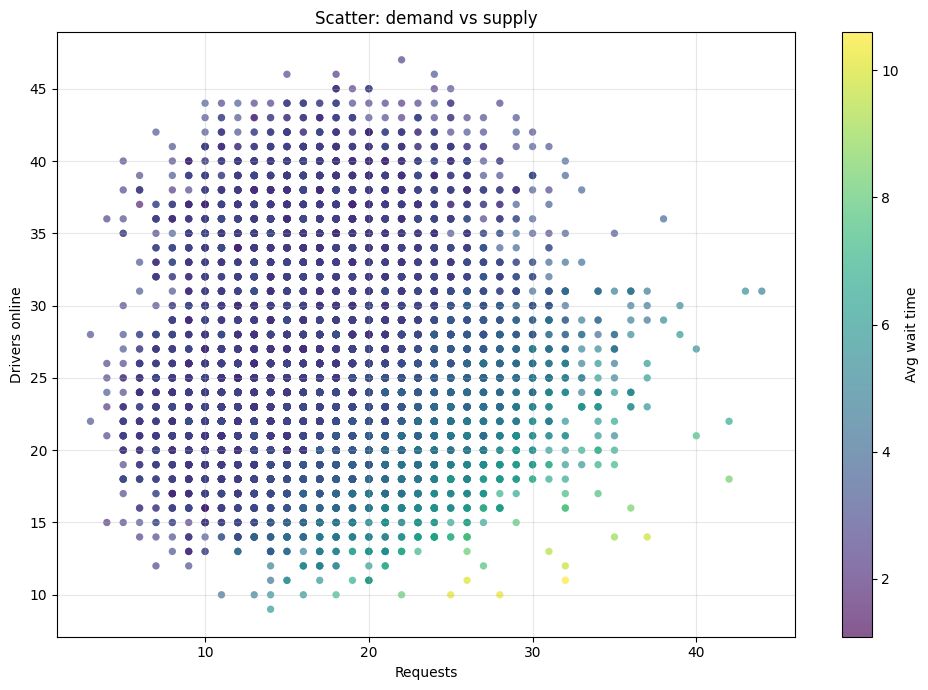

In [16]:
df_scatter = df_raw.dropna(subset=["requests", "drivers_online", "avg_wait_time"]).copy()

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    df_scatter["requests"],
    df_scatter["drivers_online"],
    c=df_scatter["avg_wait_time"],
    cmap="viridis",
    s=28,
    alpha=0.65,
    edgecolors="none",
)

ax.set_title("Scatter: demand vs supply")
ax.set_xlabel("Requests")
ax.set_ylabel("Drivers online")
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Avg wait time")

plt.tight_layout()
plt.show()

## Carryover analysis: effect of `treat_lag1`

This is very useful for switchback experiments:
- it helps identify whether there is a carryover effect
- it helps determine whether the time window is too short
- it suggests whether a lag term should be included in the model

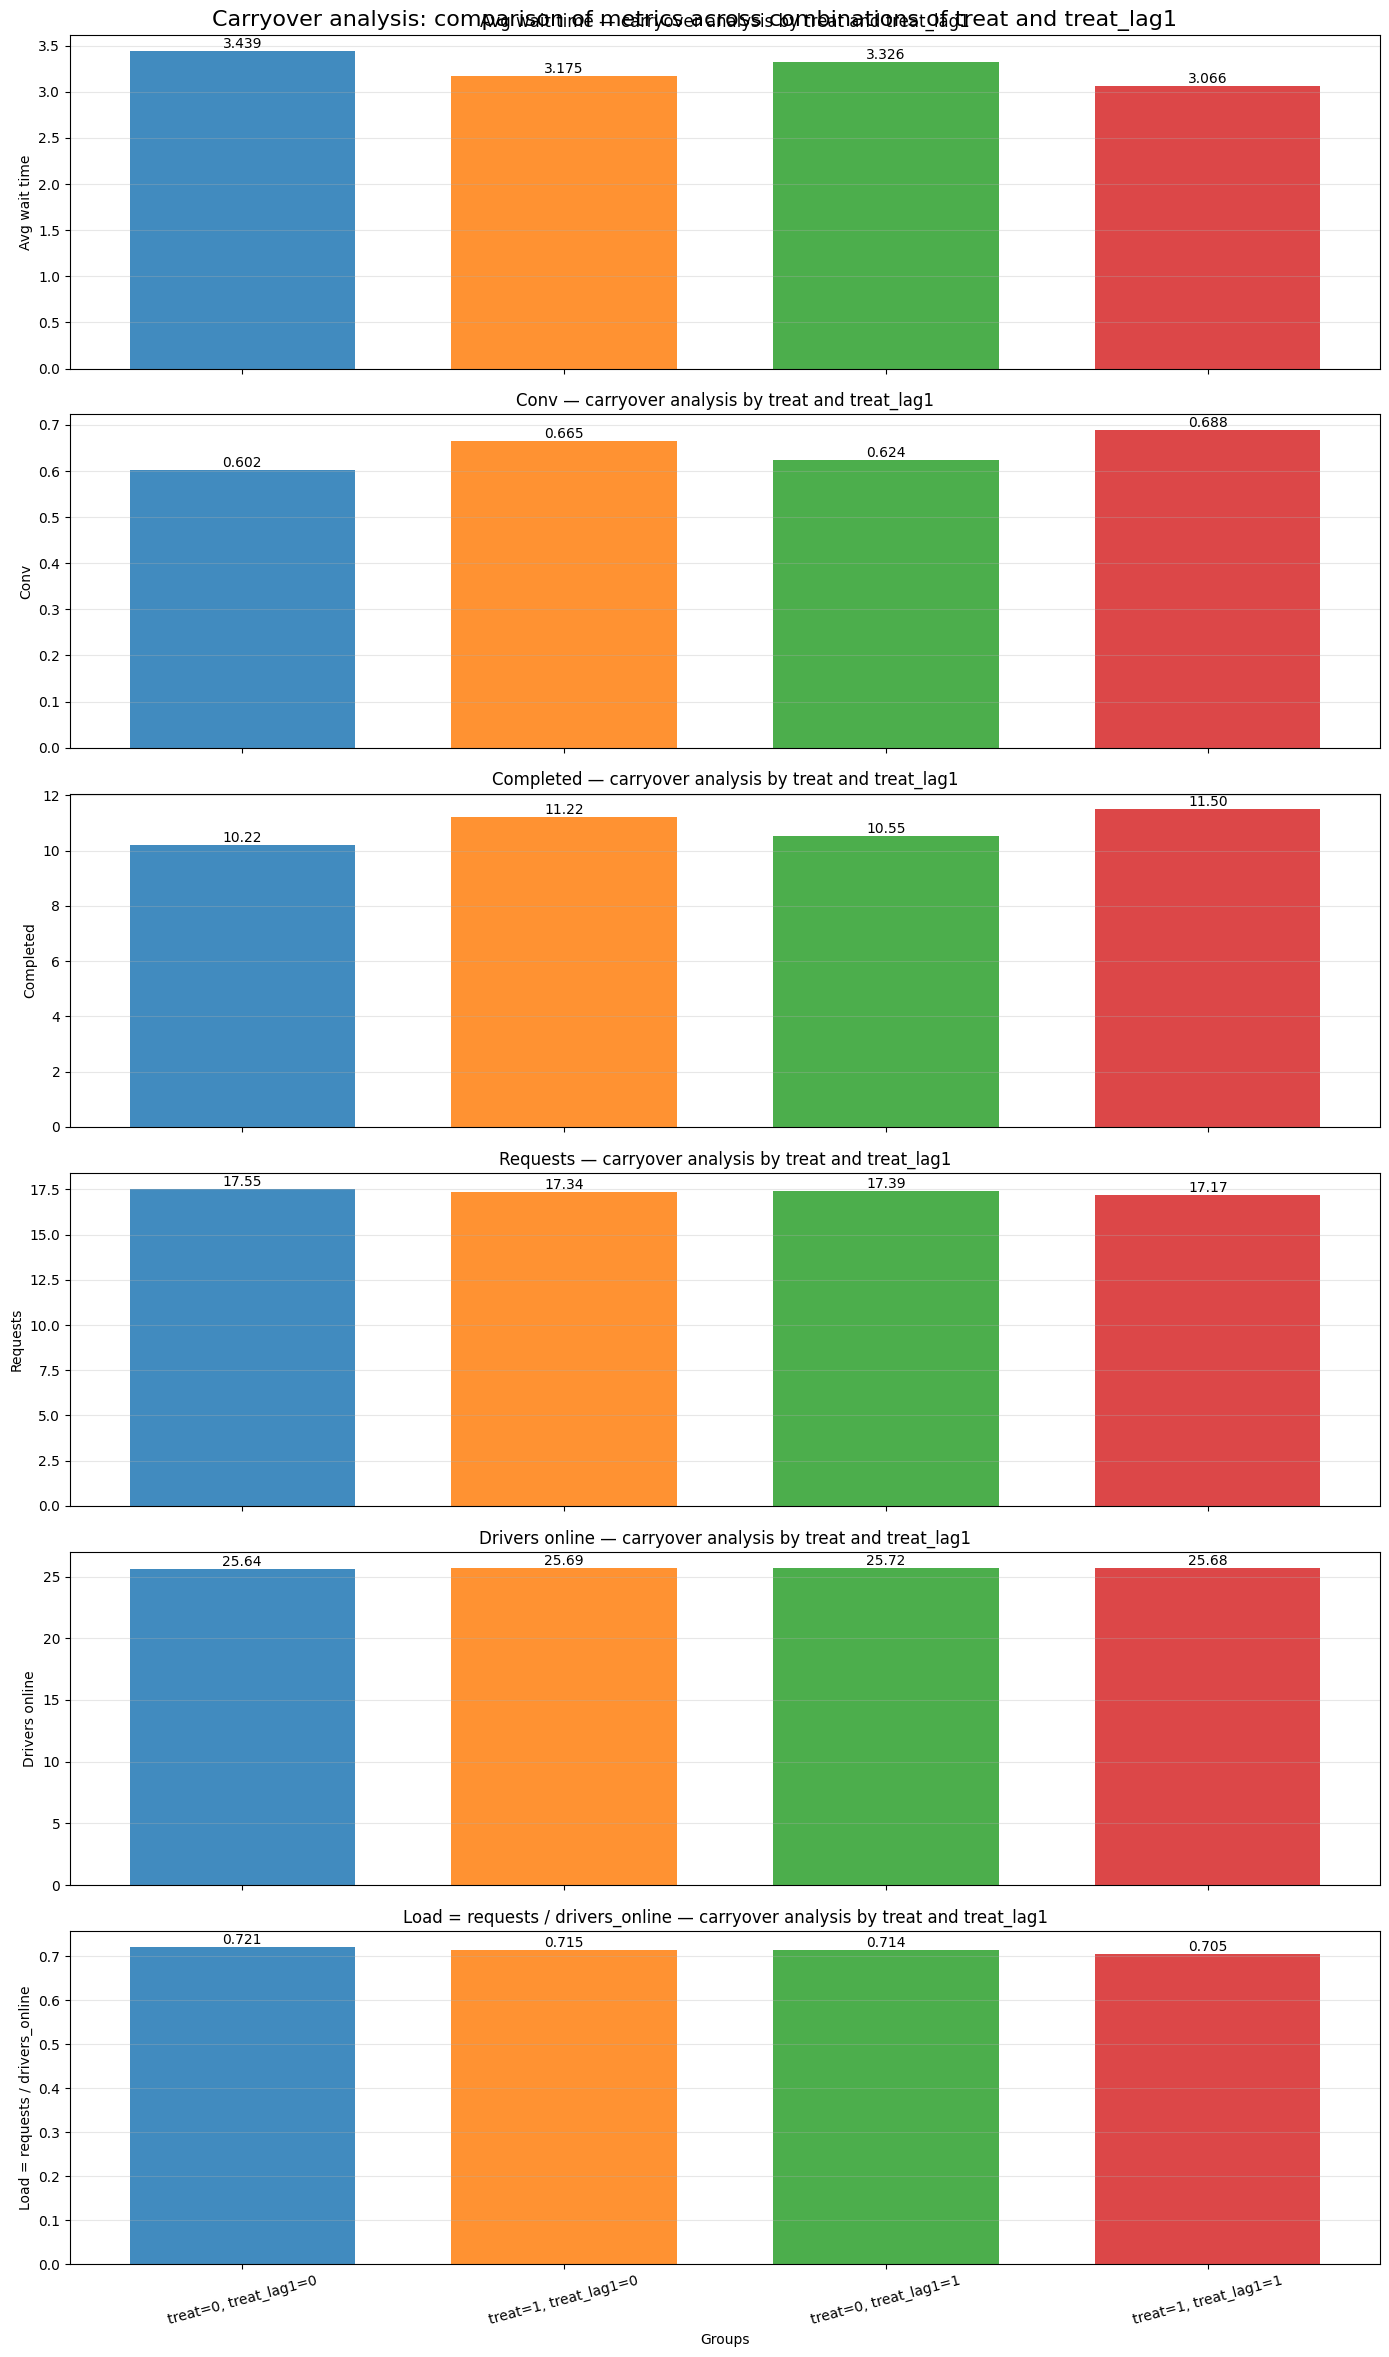

In [17]:
df_carryover = df_raw.copy()
df_carryover["load"] = df_carryover["requests"] / df_carryover["drivers_online"].replace(0, np.nan)
df_carryover["group"] = (
        "treat=" + df_carryover["treat"].astype(int).astype(str)
        + ", treat_lag1=" + df_carryover["treat_lag1"].astype(int).astype(str)
)

group_order = [
    "treat=0, treat_lag1=0",
    "treat=1, treat_lag1=0",
    "treat=0, treat_lag1=1",
    "treat=1, treat_lag1=1",
]

metrics = ["avg_wait_time", "conv", "completed", "requests", "drivers_online", "load"]
titles = {
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
    "completed": "Completed",
    "requests": "Requests",
    "drivers_online": "Drivers online",
    "load": "Load = requests / drivers_online",
}

summary_carryover = (
    df_carryover
    .groupby(["treat", "treat_lag1", "group"], as_index=False)[metrics]
    .mean()
)

summary_carryover["group"] = pd.Categorical(
    summary_carryover["group"],
    categories=group_order,
    ordered=True,
)
summary_carryover = summary_carryover.sort_values("group")

colors = {
    "treat=0, treat_lag1=0": "tab:blue",
    "treat=1, treat_lag1=0": "tab:orange",
    "treat=0, treat_lag1=1": "tab:green",
    "treat=1, treat_lag1=1": "tab:red",
}

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 24), sharex=True)
x = np.arange(len(group_order))

for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = (
        summary_carryover
        .set_index("group")
        .reindex(group_order)[metric]
        .values
    )

    ax.bar(
        x,
        vals,
        color=[colors[g] for g in group_order],
        alpha=0.85,
        width=0.7,
    )
    ax.set_title(f"{titles[metric]} — carryover analysis by treat and treat_lag1")
    ax.set_ylabel(titles[metric])
    ax.grid(True, axis="y", alpha=0.3)

    for xi, yi in zip(x, vals):
        label = f"{yi:.3f}" if metric in ["avg_wait_time", "conv", "load"] else f"{yi:.2f}"
        ax.text(xi, yi, label, ha="center", va="bottom")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(group_order, rotation=15)
axes[-1].set_xlabel("Groups")

fig.suptitle("Carryover analysis: comparison of metrics across combinations of treat and treat_lag1", fontsize=16)
plt.tight_layout()
plt.show()

## Distributions of key metrics

Why?
- to identify outliers
- to evaluate how skewed the distributions are
- to determine whether `conv` is too noisy
- to assess whether log transformations are needed

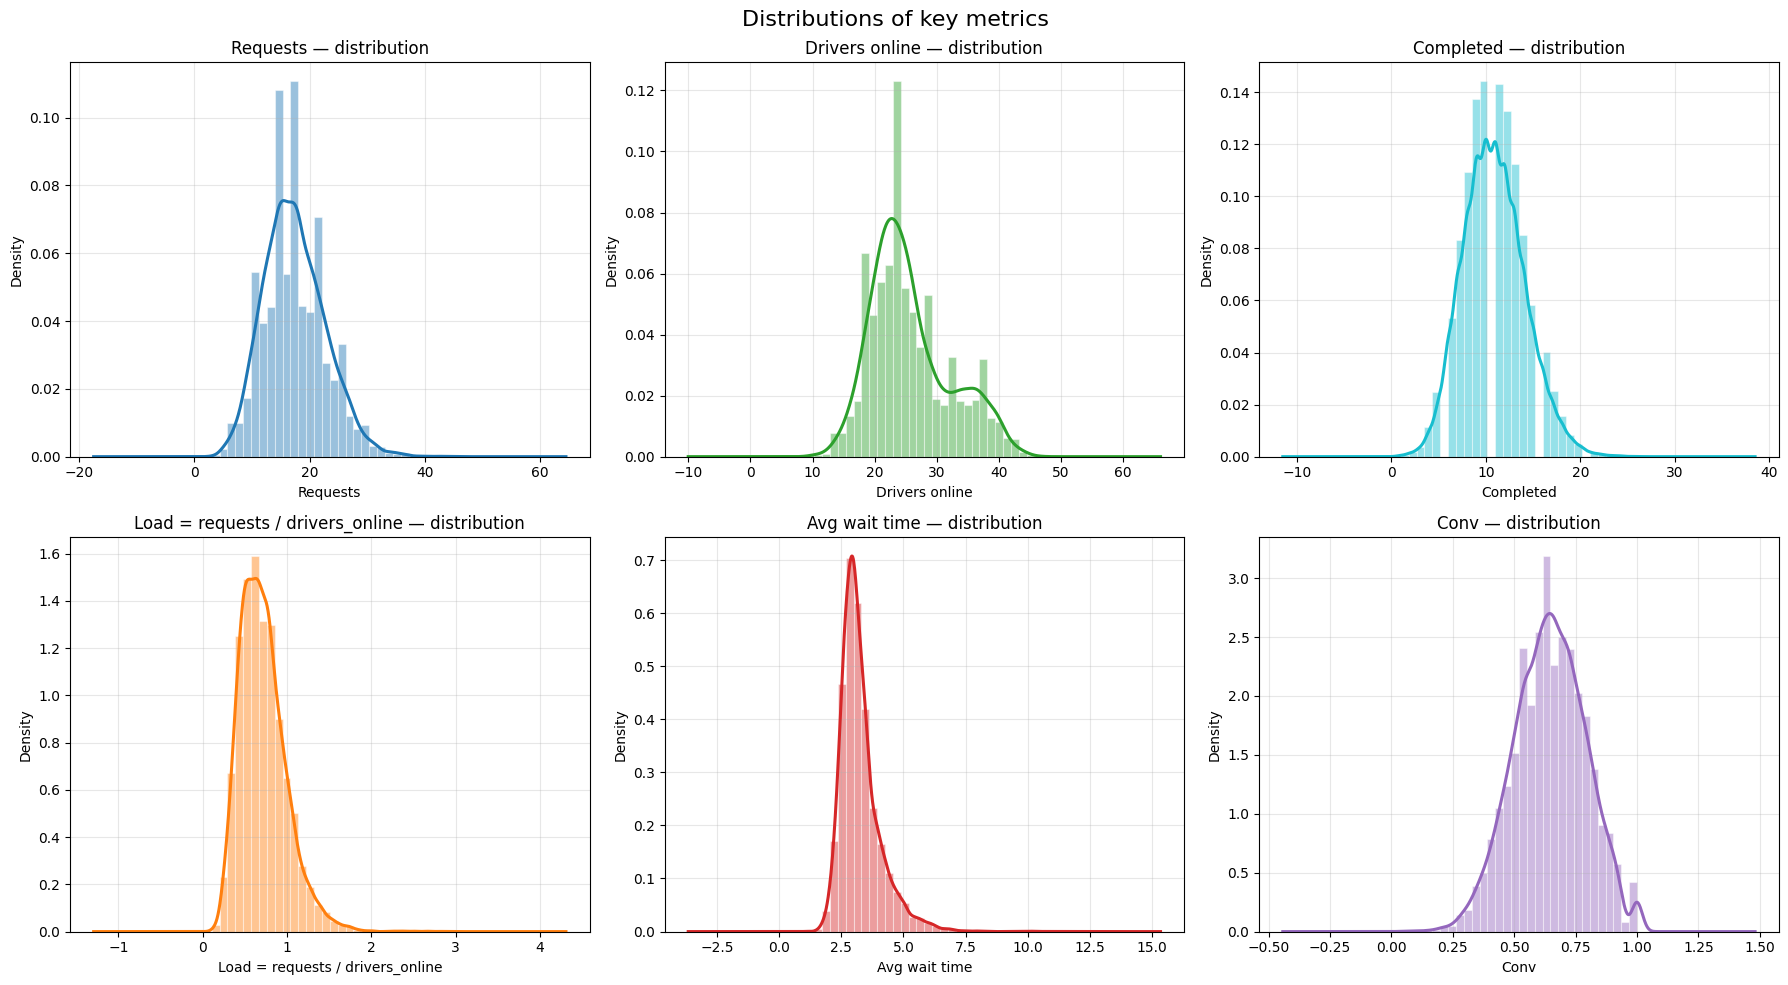

In [18]:
df_plot_dist = df_raw.copy()
df_plot_dist["load"] = df_plot_dist["requests"] / df_plot_dist["drivers_online"].replace(0, np.nan)

metrics = ["requests", "drivers_online", "completed", "load", "avg_wait_time", "conv"]
titles = {
    "requests": "Requests",
    "drivers_online": "Drivers online",
    "completed": "Completed",
    "load": "Load = requests / drivers_online",
    "avg_wait_time": "Avg wait time",
    "conv": "Conv",
}
colors = {
    "requests": "tab:blue",
    "drivers_online": "tab:green",
    "completed": "tab:cyan",
    "load": "tab:orange",
    "avg_wait_time": "tab:red",
    "conv": "tab:purple",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    s = df_plot_dist[metric].dropna()

    ax.hist(
        s,
        bins=30,
        density=True,
        alpha=0.45,
        color=colors[metric],
        edgecolor="white",
        linewidth=0.8,
    )
    s.plot(
        kind="kde",
        ax=ax,
        color=colors[metric],
        linewidth=2.2,
    )

    ax.set_title(f"{titles[metric]} — distribution")
    ax.set_xlabel(titles[metric])
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)

fig.suptitle("Distributions of key metrics", fontsize=16)
plt.tight_layout()
plt.show()

## Daily aggregate trend

Why?

It shows:
- the stability of the data generation / marketplace over days
- whether there is any drift
- whether metric changes may simply be caused by “bad days” rather than by the treatment

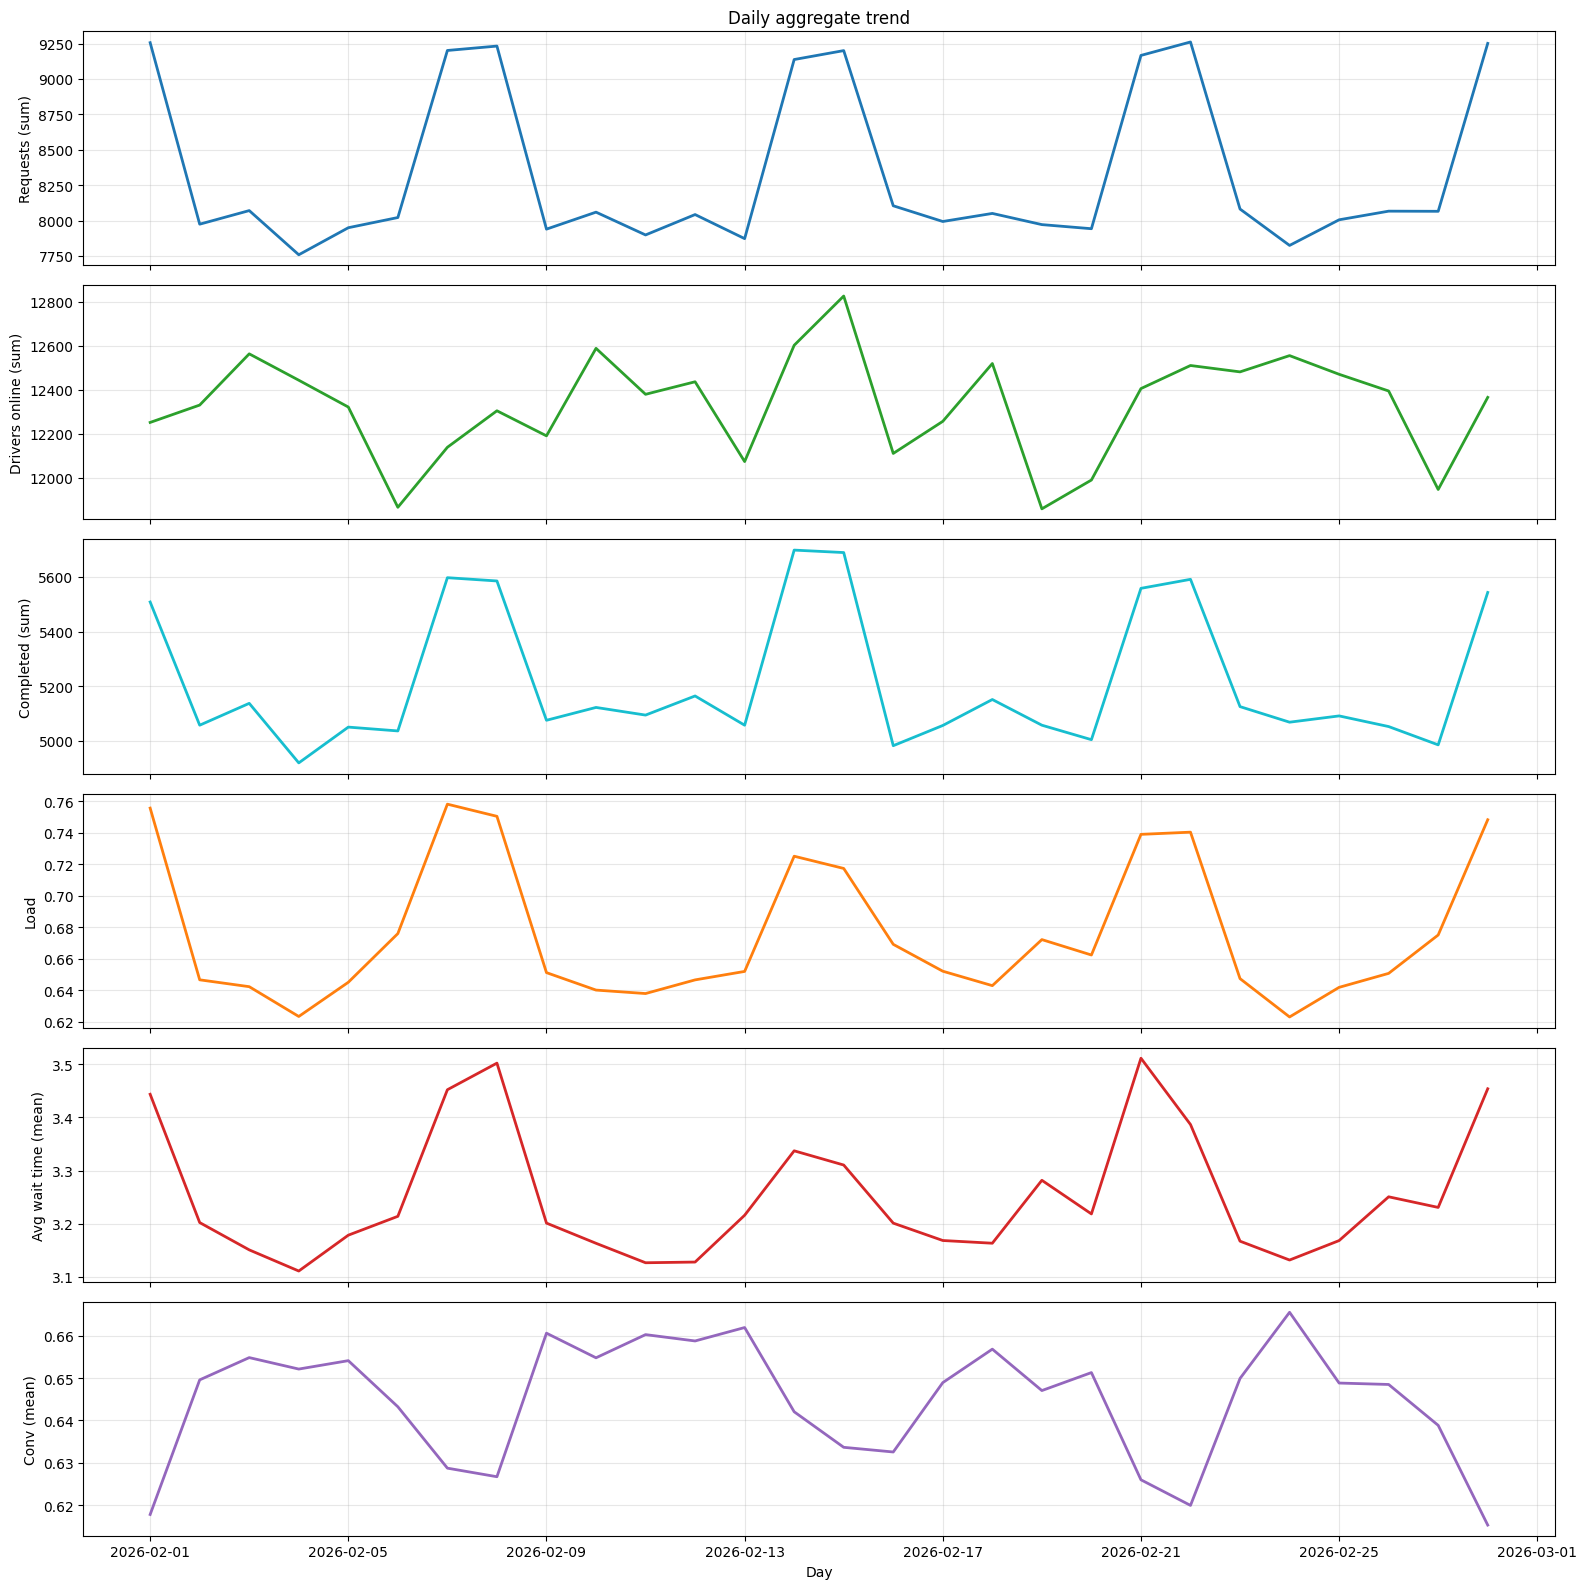

In [19]:
daily_plot = (
    df_raw
    .assign(day=pd.to_datetime(df_raw["day"]))
    .groupby("day", as_index=False)
    .agg(
        requests=("requests", "sum"),
        drivers_online=("drivers_online", "sum"),
        completed=("completed", "sum"),
        avg_wait_time=("avg_wait_time", "mean"),
        conv=("conv", "mean"),
    )
    .sort_values("day")
)

daily_plot["load"] = daily_plot["requests"] / daily_plot["drivers_online"].replace(0, np.nan)

fig, axes = plt.subplots(6, 1, figsize=(16, 16), sharex=True)

axes[0].plot(daily_plot["day"], daily_plot["requests"], color="tab:blue", linewidth=2)
axes[0].set_title("Daily aggregate trend")
axes[0].set_ylabel("Requests (sum)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_plot["day"], daily_plot["drivers_online"], color="tab:green", linewidth=2)
axes[1].set_ylabel("Drivers online (sum)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily_plot["day"], daily_plot["completed"], color="tab:cyan", linewidth=2)
axes[2].set_ylabel("Completed (sum)")
axes[2].grid(True, alpha=0.3)

axes[3].plot(daily_plot["day"], daily_plot["load"], color="tab:orange", linewidth=2)
axes[3].set_ylabel("Load")
axes[3].grid(True, alpha=0.3)

axes[4].plot(daily_plot["day"], daily_plot["avg_wait_time"], color="tab:red", linewidth=2)
axes[4].set_ylabel("Avg wait time (mean)")
axes[4].grid(True, alpha=0.3)

axes[5].plot(daily_plot["day"], daily_plot["conv"], color="tab:purple", linewidth=2)
axes[5].set_ylabel("Conv (mean)")
axes[5].set_xlabel("Day")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()